In [1]:
import os
import numpy as np
import scipy.io
import netCDF4 as nc
import h5py
import matplotlib.pyplot as plt
from shapely.geometry import shape, box, Point
from shapely.prepared import prep
import json
import glob

# Ensure plots are displayed inline
%matplotlib inline


In [2]:
# --- Configuration ---

# Input directory containing W3RA .mat files
# User Note: Change this to '/mnt/data/w3ra_era5_10km_monthly_2003_2024/' for global data
# For testing, we use the local available path:
input_dir = "/home/ubuntu/data_AOI-3/w3ra_aoi_3/" 

# Output directory
output_dir = "/home/ubuntu/work/"

# AOI Name (used for output filenames)
aoi_name = "Test_Region"

# AOI Type: 'bbox' or 'geojson'
aoi_type = "bbox" 

# AOI Parameters
# If aoi_type is 'bbox', provide [min_lon, min_lat, max_lon, max_lat]
# Example: Small box inside the available data (approx Italy/Alps region in sample)
aoi_params = [10.5, 44.5, 11.5, 45.5] 

# If aoi_type is 'geojson', provide the path to the .geojson file
# aoi_params = "path/to/aoi.geojson"


In [3]:
def get_aoi_indices(lat_array, lon_array, bbox):
    """
    Find the indices in lat_array and lon_array that correspond to the bbox.
    Assumes lat_array and lon_array are 1D and sorted (or monotonic).
    bbox: [min_lon, min_lat, max_lon, max_lat]
    """
    min_lon, min_lat, max_lon, max_lat = bbox
    
    # Find indices
    lat_inds = np.where((lat_array >= min_lat) & (lat_array <= max_lat))[0]
    lon_inds = np.where((lon_array >= min_lon) & (lon_array <= max_lon))[0]
    
    if len(lat_inds) == 0 or len(lon_inds) == 0:
        raise ValueError("No data found within the specified Bounding Box.")
        
    return lat_inds, lon_inds

def create_mask_from_geojson(geojson_path, lat_grid, lon_grid):
    """
    Create a boolean mask from a GeoJSON file.
    lat_grid, lon_grid: 2D meshgrid of latitudes and longitudes.
    Returns: boolean mask (True = inside polygon, False = outside).
    """
    with open(geojson_path) as f:
        geo_data = json.load(f)
    
    # Handle FeatureCollection or single Geometry
    if 'features' in geo_data:
        # Assuming single feature or union of features
        # For simplicity, let's take the first feature's geometry
        geom = shape(geo_data['features'][0]['geometry'])
    elif 'geometry' in geo_data:
        geom = shape(geo_data['geometry'])
    else:
        geom = shape(geo_data)
        
    prepared_geom = prep(geom)
    
    mask = np.zeros(lat_grid.shape, dtype=bool)
    
    # Iterate over grid points (this can be slow for very large grids, optimization possible)
    # For 10km global, it might take a moment. Vectorized approaches exist but require rasterio/gdal.
    # Since we don't have rasterio, we use a simple loop or vectorized check if possible.
    # Optimization: Check only points within the bbox of the polygon first.
    
    rows, cols = lat_grid.shape
    for r in range(rows):
        for c in range(cols):
            pt = Point(lon_grid[r, c], lat_grid[r, c])
            if prepared_geom.contains(pt):
                mask[r, c] = True
                
    return mask


In [4]:
# --- Main Processing ---
# This script processes W3RA .mat files, subsets them to the specified AOI,
# and saves the results in NetCDF and HDF5 formats.
# 1. Load Coordinate System
latlon_file = os.path.join(input_dir, "LatLon.mat")
if not os.path.exists(latlon_file):
    raise FileNotFoundError(f"LatLon.mat not found in {input_dir}")

print(f"Loading coordinates from {latlon_file}...")
latlon_data = scipy.io.loadmat(latlon_file, struct_as_record=False, squeeze_me=True)

# Adjust keys based on file inspection (LatLon.mat usually has lat_EU/lon_EU or similar)
# We try to find keys starting with 'lat' and 'lon'
lat_key = [k for k in latlon_data.keys() if k.startswith('lat')][0]
lon_key = [k for k in latlon_data.keys() if k.startswith('lon')][0]

lat_full = np.array(latlon_data[lat_key]).squeeze()
lon_full = np.array(latlon_data[lon_key]).squeeze()

print(f"Full Grid: Lat {lat_full.shape}, Lon {lon_full.shape}")

# 2. Determine AOI Indices
if aoi_type == 'bbox':
    bbox = aoi_params
    print(f"Selecting BBox: {bbox}")
elif aoi_type == 'geojson':
    print(f"Reading GeoJSON: {aoi_params}")
    with open(aoi_params) as f:
        geo_data = json.load(f)
    # Extract bbox from GeoJSON for initial slicing
    if 'features' in geo_data:
        geom = shape(geo_data['features'][0]['geometry'])
    else:
        geom = shape(geo_data)
    bbox = geom.bounds # (minx, miny, maxx, maxy)
    print(f"Derived BBox from GeoJSON: {bbox}")
else:
    raise ValueError("Invalid aoi_type. Choose 'bbox' or 'geojson'.")

lat_inds, lon_inds = get_aoi_indices(lat_full, lon_full, bbox)
lat_sub = lat_full[lat_inds]
lon_sub = lon_full[lon_inds]

print(f"Subset Grid: Lat {lat_sub.shape}, Lon {lon_sub.shape}")

# 3. Prepare Mask (if GeoJSON)
mask = None
if aoi_type == 'geojson':
    print("Generating GeoJSON mask...")
    lon_grid, lat_grid = np.meshgrid(lon_sub, lat_sub)
    mask = create_mask_from_geojson(aoi_params, lat_grid, lon_grid)
    print("Mask generated.")

# 4. Initialize Output Files
nc_filename = os.path.join(output_dir, f"w3ra_{aoi_name}_10km.nc")
h5_filename = os.path.join(output_dir, f"w3ra_{aoi_name}_10km.h5")

print(f"Creating outputs: {nc_filename}, {h5_filename}")

# Create NetCDF
nc_file = nc.Dataset(nc_filename, "w", format="NETCDF4")
nc_file.createDimension("lat", len(lat_sub))
nc_file.createDimension("lon", len(lon_sub))
nc_lat = nc_file.createVariable("lat", "f8", ("lat",))
nc_lon = nc_file.createVariable("lon", "f8", ("lon",))
nc_lat[:] = lat_sub
nc_lon[:] = lon_sub
nc_lat.units = "degrees_north"
nc_lon.units = "degrees_east"

# Create HDF5
h5_file = h5py.File(h5_filename, "w")
h5_file.create_dataset("lat", data=lat_sub)
h5_file.create_dataset("lon", data=lon_sub)

# 5. Process Files
mat_files = sorted([f for f in os.listdir(input_dir) if f.endswith(".mat") and "LatLon" not in f])

for mat_file in mat_files:
    # Extract year (assuming format like W3RA_..._2010.mat)
    try:
        year = int(mat_file.split("_")[-1].split(".")[0])
    except ValueError:
        print(f"Skipping {mat_file}, cannot parse year.")
        continue
        
    print(f"Processing {year}: {mat_file}")
    
    mat_path = os.path.join(input_dir, mat_file)
    mat_data = scipy.io.loadmat(mat_path, struct_as_record=False, squeeze_me=True)
    
    # Find data variables (starting with 'S')
    data_keys = [k for k in mat_data.keys() if k.startswith('S') and isinstance(mat_data[k], np.ndarray)]
    
    if not data_keys:
        continue
        
    # Create time dimension for this year in NetCDF if needed
    # Note: For a multi-year file, we might want a continuous time dim, but here we do per-year groups or vars
    # The user asked for "w3ra_<aoi>_10km.nc", implying a single file. 
    # We will append variables like "Sg_2010", "Sg_2011" etc. or use a time dimension.
    # Given the previous script structure, let's stick to separate variables or dimensions per year to be safe.
    
    days_in_year = mat_data[data_keys[0]].shape[0]
    dim_name = f"time_{year}"
    if dim_name not in nc_file.dimensions:
        nc_file.createDimension(dim_name, days_in_year)
        t_var = nc_file.createVariable(dim_name, "i4", (dim_name,))
        t_var.units = f"days since {year}-01-01"
        t_var[:] = np.arange(1, days_in_year + 1)
        
    # HDF5 Group for year
    h5_grp = h5_file.create_group(str(year))
    
    for var_name in data_keys:
        data = mat_data[var_name]
        
        if data.ndim != 3:
            continue
            
        # Slice
        # Data shape is (time, lat, lon)
        # We need to slice lat and lon. 
        # CAUTION: Check if mat file lat/lon order matches. Usually (time, lat, lon).
        
        data_sub = data[:, lat_inds[:, None], lon_inds] 
        # Note: numpy advanced indexing. lat_inds is row indices, lon_inds is col indices.
        # If lat/lon are orthogonal (grid), we use meshgrid slicing or open slicing.
        # Correct way for orthogonal grid:
        data_sub = data[:, lat_inds, :][:, :, lon_inds]
        
        # Apply Mask
        if mask is not None:
            # Broadcast mask to time dimension
            # Mask is (lat, lon), data is (time, lat, lon)
            # We set False (outside) to NaN. 
            # Wait, my mask function returns True for INSIDE.
            # So we set ~mask to NaN.
            
            # Create a full 3D mask or apply frame by frame? 
            # Broadcasting is faster.
            expanded_mask = np.broadcast_to(mask, data_sub.shape)
            data_sub = np.where(expanded_mask, data_sub, np.nan)
            
        # Write to NetCDF
        nc_var_name = f"{var_name}_{year}"
        nc_var = nc_file.createVariable(nc_var_name, "f4", (dim_name, "lat", "lon"), zlib=True)
        nc_var[:] = data_sub
        nc_var.long_name = f"{var_name} for {year}"
        
        # Write to HDF5
        h5_grp.create_dataset(var_name, data=data_sub, compression="gzip")

nc_file.close()
h5_file.close()
print("Processing complete.")


Loading coordinates from /home/ubuntu/data_AOI-3/w3ra_aoi_3/LatLon.mat...
Full Grid: Lat (22,), Lon (24,)
Selecting BBox: [10.5, 44.5, 11.5, 45.5]
Subset Grid: Lat (11,), Lon (11,)
Creating outputs: /home/ubuntu/work/w3ra_Test_Region_10km.nc, /home/ubuntu/work/w3ra_Test_Region_10km.h5
Processing 2010: W3RA_daily_10km_EU_2010.mat
Processing 2011: W3RA_daily_10km_EU_2011.mat
Processing 2012: W3RA_daily_10km_EU_2012.mat
Processing 2013: W3RA_daily_10km_EU_2013.mat
Processing 2014: W3RA_daily_10km_EU_2014.mat
Processing 2015: W3RA_daily_10km_EU_2015.mat
Processing 2016: W3RA_daily_10km_EU_2016.mat
Processing 2017: W3RA_daily_10km_EU_2017.mat
Processing 2018: W3RA_daily_10km_EU_2018.mat
Processing 2019: W3RA_daily_10km_EU_2019.mat
Processing 2020: W3RA_daily_10km_EU_2020.mat
Processing 2021: W3RA_daily_10km_EU_2021.mat
Processing 2022: W3RA_daily_10km_EU_2022.mat
Processing 2023: W3RA_daily_10km_EU_2023.mat
Processing 2024: W3RA_daily_10km_EU_2024.mat
Processing complete.


Verifying output...
NetCDF Variables: dict_keys(['lat', 'lon', 'time_2010', 'S0_EU_2010', 'Sd_EU_2010', 'Sg_EU_2010', 'Sr_EU_2010', 'Ss_EU_2010', 'Ssnow_EU_2010', 'Stot_EU_2010', 'time_2011', 'S0_EU_2011', 'Sd_EU_2011', 'Sg_EU_2011', 'Sr_EU_2011', 'Ss_EU_2011', 'Ssnow_EU_2011', 'Stot_EU_2011', 'time_2012', 'S0_EU_2012', 'Sd_EU_2012', 'Sg_EU_2012', 'Sr_EU_2012', 'Ss_EU_2012', 'Ssnow_EU_2012', 'Stot_EU_2012', 'time_2013', 'S0_EU_2013', 'Sd_EU_2013', 'Sg_EU_2013', 'Sr_EU_2013', 'Ss_EU_2013', 'Ssnow_EU_2013', 'Stot_EU_2013', 'time_2014', 'S0_EU_2014', 'Sd_EU_2014', 'Sg_EU_2014', 'Sr_EU_2014', 'Ss_EU_2014', 'Ssnow_EU_2014', 'Stot_EU_2014', 'time_2015', 'S0_EU_2015', 'Sd_EU_2015', 'Sg_EU_2015', 'Sr_EU_2015', 'Ss_EU_2015', 'Ssnow_EU_2015', 'Stot_EU_2015', 'time_2016', 'S0_EU_2016', 'Sd_EU_2016', 'Sg_EU_2016', 'Sr_EU_2016', 'Ss_EU_2016', 'Ssnow_EU_2016', 'Stot_EU_2016', 'time_2017', 'S0_EU_2017', 'Sd_EU_2017', 'Sg_EU_2017', 'Sr_EU_2017', 'Ss_EU_2017', 'Ssnow_EU_2017', 'Stot_EU_2017', 'time_201

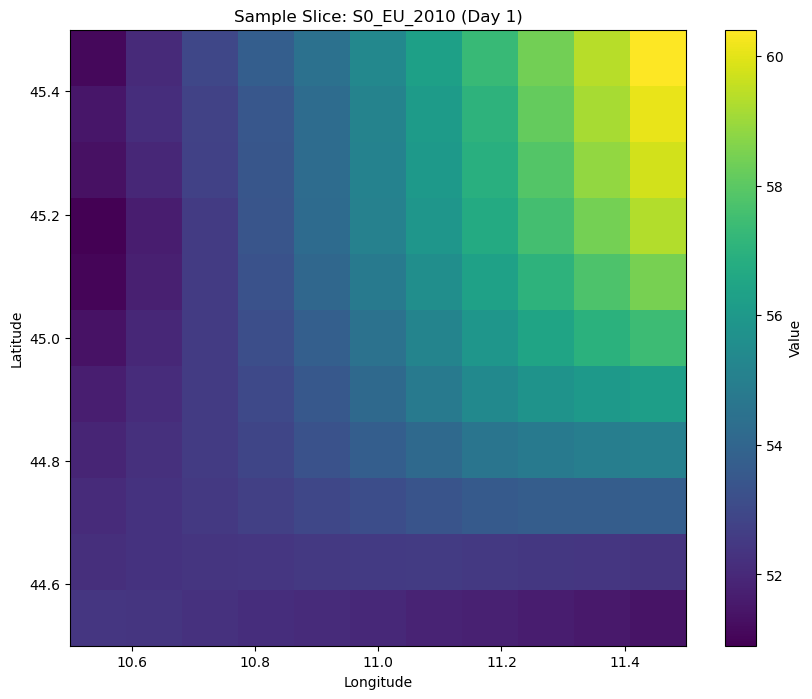

In [5]:
# --- Visualization Check ---

print("Verifying output...")
with nc.Dataset(nc_filename, "r") as ds:
    print("NetCDF Variables:", ds.variables.keys())
    
    # Plot the first variable found
    vars_to_plot = [v for v in ds.variables.keys() if v.startswith('S')]
    if vars_to_plot:
        var_name = vars_to_plot[0]
        data = ds.variables[var_name][0, :, :] # First time step
        
        plt.figure(figsize=(10, 8))
        plt.imshow(data, origin='lower', extent=[lon_sub.min(), lon_sub.max(), lat_sub.min(), lat_sub.max()])
        plt.colorbar(label='Value')
        plt.title(f"Sample Slice: {var_name} (Day 1)")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.show()
    else:
        print("No data variables found to plot.")


In [6]:
# This is a simple script to inspect the generated NetCDF file
import netCDF4 as nc
import numpy as np

nc_path = "/home/ubuntu/work/w3ra_Test_Region_10km.nc"

print("Opening NetCDF:", nc_path)
ds = nc.Dataset(nc_path, "r")

print("\n--- NetCDF Structure ---")
print("Dimensions:", dict(ds.dimensions))
print("Variables:", list(ds.variables.keys()))

# Check lat/lon
lats = ds.variables["lat"][:]
lons = ds.variables["lon"][:]
print("\nLat range:", lats.min(), "→", lats.max(), " (n =", len(lats), ")")
print("Lon range:", lons.min(), "→", lons.max(), " (n =", len(lons), ")")

# Find the first W3RA variable
data_vars = [v for v in ds.variables if v.startswith("S")]
print("\nW3RA variables:", data_vars)

# Show sample structure for first variable
v0 = data_vars[0]
arr = ds.variables[v0][:]
print(f"\nSample variable: {v0}")
print("Shape:", arr.shape)  # expect (time, lat, lon)
print("Min/Max:", np.nanmin(arr), np.nanmax(arr))

ds.close()


Opening NetCDF: /home/ubuntu/work/w3ra_Test_Region_10km.nc

--- NetCDF Structure ---
Dimensions: {'lat': "<class 'netCDF4.Dimension'>": name = 'lat', size = 11, 'lon': "<class 'netCDF4.Dimension'>": name = 'lon', size = 11, 'time_2010': "<class 'netCDF4.Dimension'>": name = 'time_2010', size = 365, 'time_2011': "<class 'netCDF4.Dimension'>": name = 'time_2011', size = 365, 'time_2012': "<class 'netCDF4.Dimension'>": name = 'time_2012', size = 366, 'time_2013': "<class 'netCDF4.Dimension'>": name = 'time_2013', size = 365, 'time_2014': "<class 'netCDF4.Dimension'>": name = 'time_2014', size = 365, 'time_2015': "<class 'netCDF4.Dimension'>": name = 'time_2015', size = 365, 'time_2016': "<class 'netCDF4.Dimension'>": name = 'time_2016', size = 366, 'time_2017': "<class 'netCDF4.Dimension'>": name = 'time_2017', size = 365, 'time_2018': "<class 'netCDF4.Dimension'>": name = 'time_2018', size = 365, 'time_2019': "<class 'netCDF4.Dimension'>": name = 'time_2019', size = 365, 'time_2020': "<c

In [7]:
# This is a simple script to inspect the generated HDF5 file
import h5py

h5_path = "/home/ubuntu/work/w3ra_Test_Region_10km.h5"
print("\nOpening HDF5:", h5_path)

with h5py.File(h5_path, "r") as f:
    print("\n--- HDF5 Groups ---")
    print(list(f.keys()))   # years + lat/lon

    # Show lat/lon
    lat = f["lat"][:]
    lon = f["lon"][:]
    print("Lat range:", lat.min(), lat.max(), " (n =", len(lat), ")")
    print("Lon range:", lon.min(), lon.max(), " (n =", len(lon), ")")

    # Inspect a sample year
    year = "2015"
    print(f"\nVariables in {year}:", list(f[year].keys()))

    # Load an example
    sample_key = list(f[year].keys())[0]
    data = f[f"{year}/{sample_key}"][:]

    print(f"\nSample variable: {sample_key}")
    print("Shape:", data.shape)
    print("Min/Max:", data.min(), data.max())



Opening HDF5: /home/ubuntu/work/w3ra_Test_Region_10km.h5

--- HDF5 Groups ---
['2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', 'lat', 'lon']
Lat range: 44.5 45.5  (n = 11 )
Lon range: 10.5 11.5  (n = 11 )

Variables in 2015: ['S0_EU', 'Sd_EU', 'Sg_EU', 'Sr_EU', 'Ss_EU', 'Ssnow_EU', 'Stot_EU']

Sample variable: S0_EU
Shape: (365, 11, 11)
Min/Max: 15.649183059304223 60.43043690756809


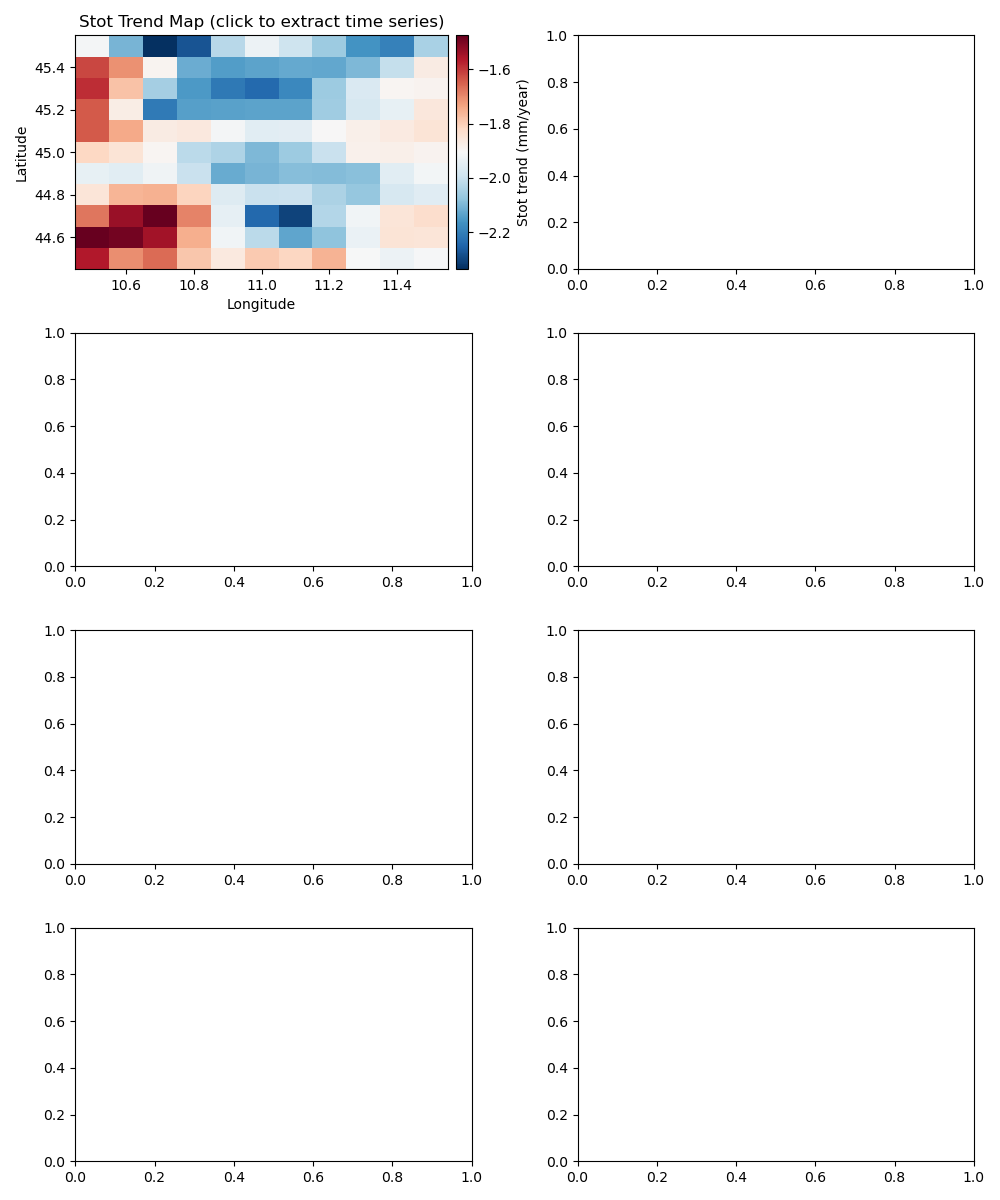

In [8]:
%matplotlib widget
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt

# -------------------------------
# Open W3RA subset NetCDF
# -------------------------------
ds_nc = nc.Dataset("/home/ubuntu/work/w3ra_Test_Region_10km.nc")

# lat/lon as plain NumPy arrays
lat = np.array(ds_nc["lat"][:])   # (Ny,)
lon = np.array(ds_nc["lon"][:])   # (Nx,)

# All variable names starting with "S"
vars_all = [v for v in ds_nc.variables.keys() if v.startswith("S")]
layers   = ["S0", "Sd", "Sg", "Sr", "Ss", "Ssnow", "Stot"]


# -------------------------------
# Helper: load one layer over full time span
# -------------------------------
def load_layer(layer):
    """Return (data, time) for full 2010-2024 for one layer."""
    # match keys like "Sd_EU_2010"
    years = sorted(
        int(v.split("_EU_")[-1])
        for v in vars_all if v.startswith(layer + "_EU_")
    )
    if len(years) == 0:
        print("⚠ No matching variables for:", layer)
        return None, None

    all_data = []
    all_time = []

    for y in years:
        key_data = f"{layer}_EU_{y}"
        key_time = f"time_{y}"

        if key_data not in ds_nc.variables:
            print("⚠ Missing:", key_data)
            continue

        arr = np.array(ds_nc[key_data][:])       # (T, Ny, Nx)
        t_days = np.array(ds_nc[key_time][:])    # (T,)

        # Convert "days since YYYY-01-01" → datetime
        base = dt.date(y, 1, 1)
        t = np.array([base + dt.timedelta(days=float(dd)) for dd in t_days])

        all_data.append(arr)
        all_time.append(t)

    if len(all_data) == 0:
        print("Load layer failed for:", layer)
        return None, None

    data = np.concatenate(all_data, axis=0)   # (T, Ny, Nx)
    time = np.concatenate(all_time, axis=0)   # (T,)
    return data, time


# -------------------------------
# Trend of Stot (mm/year)
# -------------------------------
def trend_1d(x, t_num):
    """Linear trend of x over t_num (years). Return slope [mm/year] as scalar."""
    A = np.vstack([t_num, np.ones_like(t_num)]).T  # (T,2)
    coeffs, *_ = np.linalg.lstsq(A, x, rcond=None)
    m = coeffs[0]          # slope
    return float(m)        # make sure it is a scalar


# Load Stot
stot, t_stot = load_layer("Stot")   # stot [mm], shape (T, Ny, Nx)
T, Ny, Nx = stot.shape

# numeric time in years from start
t0 = t_stot[0]
t_num = np.array([(tt - t0).days / 365.25 for tt in t_stot])

# compute trend per pixel
trend_map = np.empty((Ny, Nx), dtype=float)
for iy in range(Ny):
    for ix in range(Nx):
        trend_map[iy, ix] = trend_1d(stot[:, iy, ix], t_num)
# trend_map in mm/year


# -------------------------------
# Figure layout
# -------------------------------
fig = plt.figure(figsize=(10, 12))

ax_map = fig.add_subplot(4, 2, 1)
axes_ts = [fig.add_subplot(4, 2, i + 2) for i in range(7)]

# plot trend map
im = ax_map.pcolormesh(lon, lat, trend_map, cmap="RdBu_r", shading="auto")
cb = plt.colorbar(im, ax=ax_map, fraction=0.04, pad=0.02)
cb.set_label("Stot trend (mm/year)")
ax_map.set_title("Stot Trend Map (click to extract time series)")
ax_map.set_xlabel("Longitude")
ax_map.set_ylabel("Latitude")

# cache for loaded layers
cache = {}

lat_arr = lat
lon_arr = lon


# -------------------------------
# Click callback
# -------------------------------
def on_click(event):
    if event.inaxes is not ax_map:
        return

    lon_pt = float(event.xdata)
    lat_pt = float(event.ydata)

    # nearest grid index
    iy = int(np.argmin(np.abs(lat_arr - lat_pt)))
    ix = int(np.argmin(np.abs(lon_arr - lon_pt)))

    fig.suptitle(f"Time series at lat={lat_arr[iy]:.4f}, lon={lon_arr[ix]:.4f}")

    # update all 7 panels
    for ax, layer in zip(axes_ts, layers):
        # load layer if not cached
        if layer not in cache:
            d, t = load_layer(layer)
            cache[layer] = (d, t)
        d, t = cache[layer]
        if d is None:
            continue

        ts = d[:, iy, ix]  # (T,)

        ax.clear()
        ax.plot(t, ts, "k-")
        ax.set_title(layer)
        ax.set_ylabel("mm")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    fig.canvas.draw_idle()


cid = fig.canvas.mpl_connect("button_press_event", on_click)

plt.tight_layout()
plt.show()


In [9]:
print(vars_all)


['S0_EU_2010', 'Sd_EU_2010', 'Sg_EU_2010', 'Sr_EU_2010', 'Ss_EU_2010', 'Ssnow_EU_2010', 'Stot_EU_2010', 'S0_EU_2011', 'Sd_EU_2011', 'Sg_EU_2011', 'Sr_EU_2011', 'Ss_EU_2011', 'Ssnow_EU_2011', 'Stot_EU_2011', 'S0_EU_2012', 'Sd_EU_2012', 'Sg_EU_2012', 'Sr_EU_2012', 'Ss_EU_2012', 'Ssnow_EU_2012', 'Stot_EU_2012', 'S0_EU_2013', 'Sd_EU_2013', 'Sg_EU_2013', 'Sr_EU_2013', 'Ss_EU_2013', 'Ssnow_EU_2013', 'Stot_EU_2013', 'S0_EU_2014', 'Sd_EU_2014', 'Sg_EU_2014', 'Sr_EU_2014', 'Ss_EU_2014', 'Ssnow_EU_2014', 'Stot_EU_2014', 'S0_EU_2015', 'Sd_EU_2015', 'Sg_EU_2015', 'Sr_EU_2015', 'Ss_EU_2015', 'Ssnow_EU_2015', 'Stot_EU_2015', 'S0_EU_2016', 'Sd_EU_2016', 'Sg_EU_2016', 'Sr_EU_2016', 'Ss_EU_2016', 'Ssnow_EU_2016', 'Stot_EU_2016', 'S0_EU_2017', 'Sd_EU_2017', 'Sg_EU_2017', 'Sr_EU_2017', 'Ss_EU_2017', 'Ssnow_EU_2017', 'Stot_EU_2017', 'S0_EU_2018', 'Sd_EU_2018', 'Sg_EU_2018', 'Sr_EU_2018', 'Ss_EU_2018', 'Ssnow_EU_2018', 'Stot_EU_2018', 'S0_EU_2019', 'Sd_EU_2019', 'Sg_EU_2019', 'Sr_EU_2019', 'Ss_EU_2019', 'S

In [10]:
for layer in ["S0","Ss","Sd","Sr","Ssnow","Sg","Stot"]:
    d, t = load_layer(layer)
    print(layer, d.shape, len(t))


S0 (5326, 11, 11) 5326
Ss (5326, 11, 11) 5326
Sd (5326, 11, 11) 5326
Sr (5326, 11, 11) 5326
Ssnow (5326, 11, 11) 5326
Sg (5326, 11, 11) 5326
Stot (5326, 11, 11) 5326


In [11]:
# This script computes synthetic vertical displacements from W3RA loading data using FFT-based convolution
# And save outputs to NetCDF files as uz_load_cm.nc, uz_poro_cm.nc, uz_total_cm.nc
import numpy as np
import netCDF4 as nc
import xarray as xr
import datetime as dt

# ============================================================
# 1. LOAD W3RA
# ============================================================

nc_path = "/home/ubuntu/work/w3ra_Test_Region_10km.nc"
ds_nc = nc.Dataset(nc_path)

lat = ds_nc["lat"][:]
lon = ds_nc["lon"][:]
Nx = len(lon)
Ny = len(lat)

vars_all = [v for v in ds_nc.variables if v.startswith("S")]

layers_load = ["S0", "Ss", "Sd", "Sr", "Ssnow"]  # elastic load layers
layers_poro = ["Sg"]                             # poroelastic layer


# ============================================================
# 2. LOAD LAYER AS [T,Y,X] AND COMPUTE ANOMALIES
# ============================================================

def load_layer(layer):
    # Match EXACT variable names like: "Sd_EU_2010"
    years = sorted([
        v.split("_EU_")[-1]
        for v in vars_all
        if v.startswith(f"{layer}_EU_")
    ])

    if len(years) == 0:
        print("! No matching variables for:", layer)
        return None, None

    all_data, all_time = [], []

    for y in years:
        key = f"{layer}_EU_{y}"
        if key not in ds_nc.variables:
            print("! Missing:", key)
            continue

        arr = ds_nc[key][:]               # (T,Y,X)
        d   = ds_nc[f"time_{y}"][:]

        base = dt.date(int(y), 1, 1)
        t = np.array([base + dt.timedelta(days=float(dd)) for dd in d])

        all_data.append(arr)
        all_time.append(t)

    # Final safety check
    if len(all_data) == 0:
        print("X load_layer FAILED for:", layer)
        return None, None

    return np.concatenate(all_data), np.concatenate(all_time)


# LOAD ALL LAYERS
data = {}
for layer in layers_load + layers_poro:
    d, t = load_layer(layer)
    data[layer] = d
    time = t   # same time axis for all


# ANOMALIES
anom = {}
for layer in data:
    mean = data[layer].mean(axis=0, keepdims=True)   # shape (1,Y,X)
    anom[layer] = data[layer] - mean                  # shape (T,Y,X)


In [12]:

# The parameters and grid spacing used for kernel computation
# PARAMETERS (set your own values)
E  = 1e9          # Young's modulus (Pa)
nu = 0.25         # Poisson ratio
rho_w = 1000      # kg/m3
g = 9.81
alpha = 0.8       # Biot coefficient
Hg = 150           # aquifer thickness (m)
Seff = 0.2        # effective storage coefficient
a = 3000         # compact kernel radius (m)

# GRID SPACING (in meters)
dx = 10000        # adjust to your AOI resolution (10 km)
dy = 10000





In [13]:
import numpy as np

# This module builds elastic and poroelastic kernels for vertical displacement calculations
# Based on elastic half-space theory and poroelastic response. Ref: Landry et al., 2017?? Wang ??
# ------------------------------
# 1. ELASTIC LOAD KERNEL
# ------------------------------
def build_elastic_kernel(E, nu, dx, dy, a, Nx, Ny):
    """
    Returns G_load_z on (Ny, Nx) grid.
    """
    # Build coordinate grid
    xgrid = (np.arange(Nx) - Nx/2) * dx
    ygrid = (np.arange(Ny) - Ny/2) * dy
    XX, YY = np.meshgrid(xgrid, ygrid)
    r = np.sqrt(XX**2 + YY**2)
    r[r < 1e-6] = 1e-6

    # Vertical elastic response to surface load
    G_load_z = (1 + nu) / (np.pi * E * (1 - nu)) * (1 - np.exp(-r / a)) / r

    return G_load_z



# ------------------------------
# 2. POROELASTIC KERNEL
# ------------------------------
def build_poroelastic_kernel(E, nu, alpha, Hg, dx, dy, a, Nx, Ny):
    """
    Returns G_poro_z on (Ny, Nx) grid.
    """
    xgrid = (np.arange(Nx) - Nx/2) * dx
    ygrid = (np.arange(Ny) - Ny/2) * dy
    XX, YY = np.meshgrid(xgrid, ygrid)
    r = np.sqrt(XX**2 + YY**2)
    r[r < 1e-6] = 1e-6

    G_poro_z = alpha * (1 + nu) * Hg * 9.81 / (np.pi * E * (1 - nu)) * (1 - np.exp(-r / a)) / r

    return G_poro_z




# ------------------------------
# 3. FFT KERNEL BUILDER
# ------------------------------
def build_fft_kernels(G_load_z, G_poro_z):
    G_load_fft = np.fft.fft2(np.fft.ifftshift(G_load_z))
    G_poro_fft = np.fft.fft2(np.fft.ifftshift(G_poro_z))
    return G_load_fft, G_poro_fft



In [14]:
G_load_z = build_elastic_kernel(E, nu, dx, dy, a, Nx, Ny)
G_poro_z = build_poroelastic_kernel(E, nu, alpha, Hg, dx, dy, a, Nx, Ny)

G_load_fft, G_poro_fft = build_fft_kernels(G_load_z, G_poro_z)


In [15]:
T = len(time)

uz_load = np.zeros((T, Ny, Nx))
uz_poro = np.zeros((T, Ny, Nx))

# PRECOMPUTE PORE PRESSURE
delta_p = rho_w * g * (anom["Sg"] / Seff)      # (T,Y,X)

# PRECOMPUTE SURFACE LOAD (sum of 5 layers)
delta_L = rho_w * sum(anom[layer] for layer in layers_load)

# FOR EACH TIME STEP
for i in range(T):
    # ----- ELASTIC LOAD -----
    L_fft = np.fft.fft2(delta_L[i])
    Uz_fft = G_load_fft * L_fft
    uz_load[i] = np.fft.ifft2(Uz_fft).real

    # ----- POROELASTIC -----
    P_fft = np.fft.fft2(delta_p[i])
    Uzp_fft = G_poro_fft * P_fft
    uz_poro[i] = np.fft.ifft2(Uzp_fft).real

# TOTAL
uz_total = uz_load + uz_poro

# CONVERT TO CM
uz_load_cm  = uz_load  * 100
uz_poro_cm  = uz_poro  * 100
uz_total_cm = uz_total * 100


In [37]:

# ============================================================
# 6. SAVE OUTPUTS
# ============================================================
time64 = np.array(time, dtype="datetime64[ns]")

def save_nc(fname, arr):
    da = xr.DataArray(
        arr,
        dims=("time", "lat", "lon"),
        coords={"time": time64, "lat": lat, "lon": lon},
        name="uz_cm"
    )
    da.attrs["units"] = "cm"
    da.attrs["description"] = "Synthetic vertical displacement"
    da.to_netcdf(fname)
    print("Saved:", fname)


# convert Python datetime -> numpy datetime64

save_nc("/home/ubuntu/work/uz_load_cm.nc",  uz_load_cm)
save_nc("/home/ubuntu/work/uz_poro_cm.nc",  uz_poro_cm)
save_nc("/home/ubuntu/work/uz_total_cm.nc", uz_total_cm)


Saved: /home/ubuntu/work/uz_load_cm.nc
Saved: /home/ubuntu/work/uz_poro_cm.nc
Saved: /home/ubuntu/work/uz_total_cm.nc


In [16]:
# =========================================
# A. ADD REALISTIC NOISE TO SYNTHETIC DATA
# =========================================
# This section adds white noise, correlated noise, and seasonal signals
# to the synthetic vertical displacement data (uz_total_cm).
import numpy as np

T, Ny, Nx = uz_total_cm.shape

# ---- 1. White noise (3 mm) ----
sigma_white = 0.03   # cm
white_noise = sigma_white * np.random.randn(T, Ny, Nx)

# ---- 2. Correlated 2D noise per epoch ----
def powerlaw_noise_2d(nx, ny, alpha=1.5):
    kx = np.fft.fftfreq(nx)
    ky = np.fft.fftfreq(ny)
    KX, KY = np.meshgrid(kx, ky)
    K = np.sqrt(KX**2 + KY**2)
    K[0,0] = 1.0
    amp = 1.0 / (K**alpha)
    phase = np.exp(1j * 2 * np.pi * np.random.rand(ny, nx))
    field = np.real(np.fft.ifft2(amp * phase))
    field = field - np.mean(field)
    field = field / np.std(field)
    return field

A_corr = 0.1   # cm ≈ 1 mm
corr_noise = np.zeros_like(uz_total_cm)
for i in range(T):
    corr_noise[i] = A_corr * powerlaw_noise_2d(Nx, Ny, alpha=1.5)

# ---- 3. Seasonal noise ----
t = np.arange(T)
seasonal = (0.05 * np.sin(2*np.pi*t/365.25) +
            0.03 * np.sin(4*np.pi*t/365.25))
seasonal = seasonal[:, None, None]

# ---- 4. Noisy synthetic deformation ----
uz_total_noisy_cm = uz_total_cm + white_noise + corr_noise + seasonal


In [18]:
# This section prepares the noisy synthetic data for plotting and analysis 
# As an alternative for the previous NetCDF structure for saving the noisy data
import xarray as xr
import numpy as np
import matplotlib.dates as mdates

# time64 already exists from before (used in save_nc)
time64 = np.array(time, dtype="datetime64[ns]")

ds_noisy = xr.Dataset(
    {
        "uz_cm": (("time", "lat", "lon"), uz_total_noisy_cm)
    },
    coords={
        "time": time64,
        "lat": lat,
        "lon": lon,
    },
)

# Now mimic the old variables
uz = ds_noisy["uz_cm"]
t = ds_noisy["time"].values
t_plot = mdates.date2num(t)


In [ ]:
# This script csaves and prints synthetic datasets with added noise
save_nc("/home/ubuntu/work/uz_total_noisy_cm.nc", uz_total_noisy_cm)
print("Synthetic datasets saved.")


In [59]:
# This is an interactive script to visualize the noisy synthetic vertical displacement data
# and extract time series at clicked locations
%matplotlib widget
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [19]:
# This is to use the noisy dataset if not aimed to load the saved one  
ds = ds_noisy

In [32]:

# --- Load dataset ---
# ds = xr.open_dataset("/home/ubuntu/work/uz_total_noisy_cm.nc")
uz = ds['uz_cm']                     # (time, lat, lon)
lat = ds['lat'].values
lon = ds['lon'].values
t = ds['time'].values                # datetime64 array
t_plot = mdates.date2num(t)          # convert to float for plotting


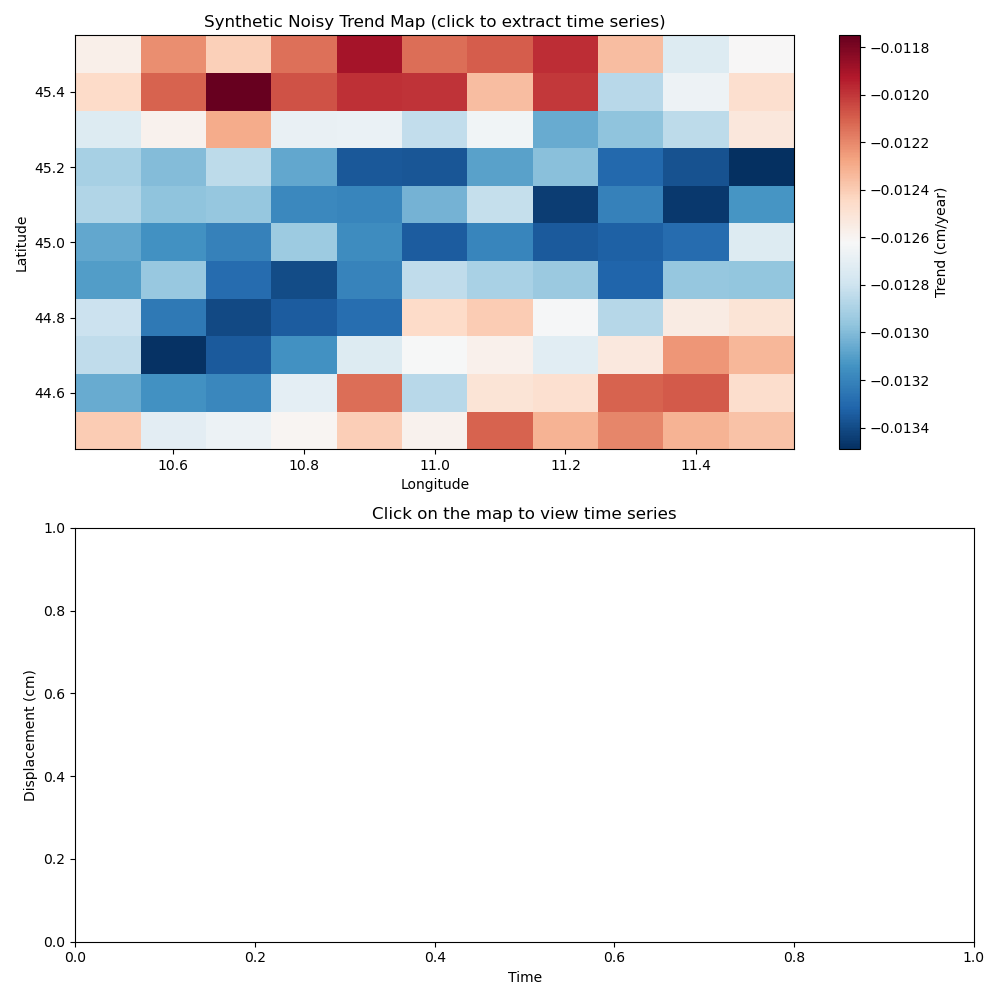

In [33]:


# --- Compute trend map for the upper panel (optional) ---
def linear_trend(x):
    t = np.arange(len(x))
    m = np.polyfit(t, x, 1)[0]
    return m * 365.25   # convert slope (per index) to per year

trend_map = np.apply_along_axis(linear_trend, 0, uz.values)


# --- Figure Layout ---
fig = plt.figure(figsize=(10, 10))

# Top ax: Trend map
ax_map = fig.add_subplot(2, 1, 1)
im = ax_map.pcolormesh(lon, lat, trend_map, cmap="RdBu_r", shading="auto")
plt.colorbar(im, ax=ax_map, label="Trend (cm/year)")
ax_map.set_title("Synthetic Noisy Trend Map (click to extract time series)")
ax_map.set_ylabel("Latitude")
ax_map.set_xlabel("Longitude")

# Bottom ax: Time series
ax_ts = fig.add_subplot(2, 1, 2)
ax_ts.set_title("Click on the map to view time series")
ax_ts.set_ylabel("Displacement (cm)")
ax_ts.set_xlabel("Time")

# Lat-lon text label
latlon_text = ax_ts.text(
    0.02, 0.92, "",
    transform=ax_ts.transAxes,
    fontsize=11
)


# --- On-click callback ---
def onclick(event):
    if event.inaxes != ax_map:
        return

    # nearest pixel
    lon_pt, lat_pt = event.xdata, event.ydata
    iy = np.argmin(np.abs(lat - lat_pt))
    ix = np.argmin(np.abs(lon - lon_pt))

    # display coordinates
    latlon_text.set_text(f"Lat={lat_pt:.4f}, Lon={lon_pt:.4f}")

    # extract time series
    ts = uz.isel(lat=iy, lon=ix).values

    # Update TS plot
    ax_ts.cla()
    ax_ts.plot(t_plot, ts, 'k-', linewidth=0.8)
    ax_ts.set_ylabel("cm")
    ax_ts.set_title(f"Time Series at Lat={lat_pt:.4f}, Lon={lon_pt:.4f}")
    ax_ts.xaxis.set_major_locator(mdates.YearLocator())
    ax_ts.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # redraw
    fig.canvas.draw_idle()


# --- Connect ---
fig.canvas.mpl_connect("button_press_event", onclick)

plt.tight_layout()
plt.show()


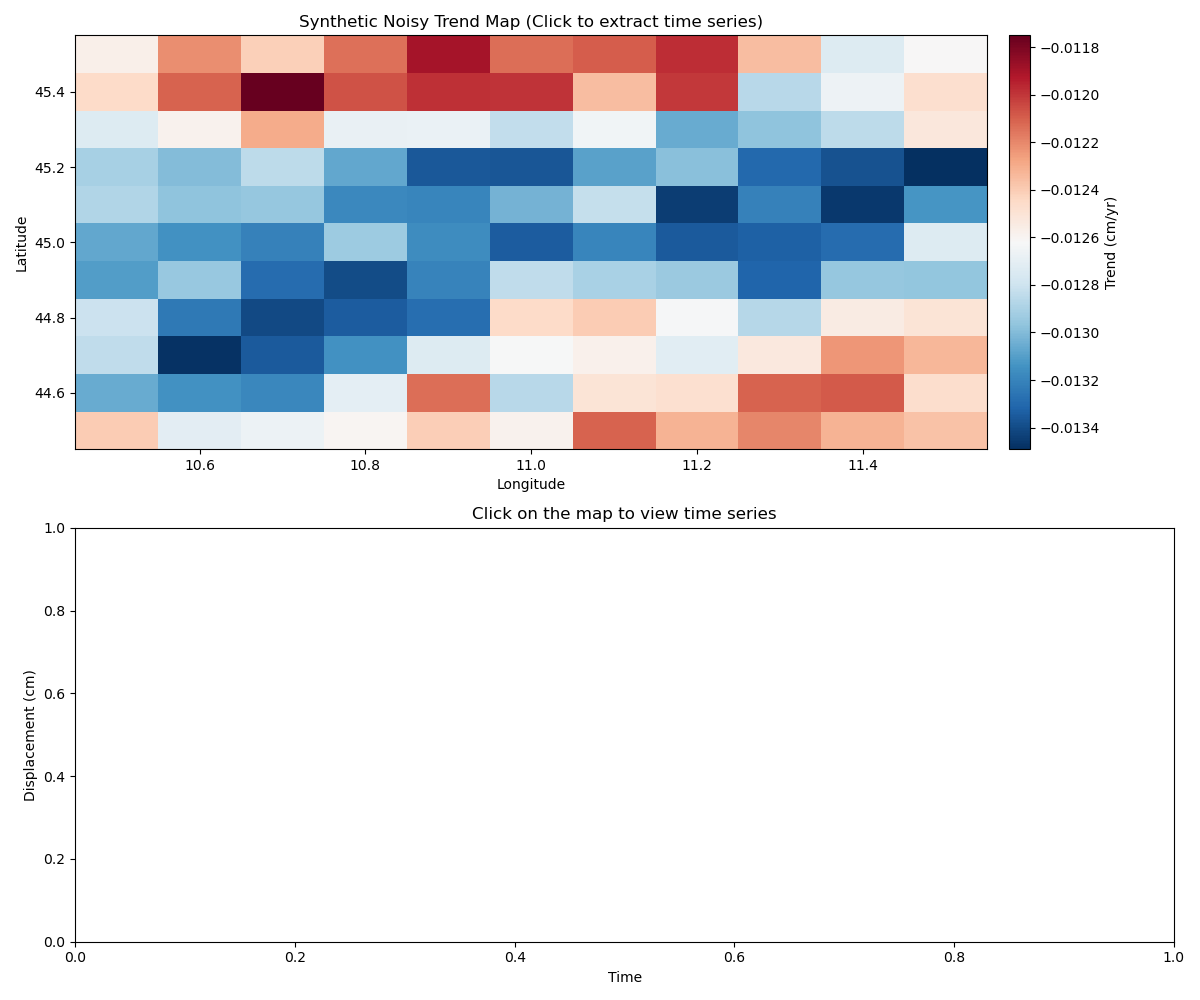

In [34]:
# This is an interactive script to visualize trend map and extract time series
# from the noisy synthetic vertical displacement data
%matplotlib widget
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------------------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------------------
# ds = xr.open_dataset("/home/ubuntu/work/uz_total_noisy_cm.nc")

time = ds["time"].values
lat  = ds["lat"].values
lon  = ds["lon"].values
uz   = ds["uz_cm"].values   # (time, lat, lon)

# Compute linear trend for each grid cell
def linear_trend(x):
    t = np.arange(len(x))
    m, _ = np.linalg.lstsq(
        np.vstack([t, np.ones_like(t)]).T, x, rcond=None
    )[0]
    return m * 365.25  # per year

trend_map = np.apply_along_axis(linear_trend, 0, uz)

# ---------------------------------------------------------
# 2. FIGURE LAYOUT
# ---------------------------------------------------------
fig = plt.figure(figsize=(12, 10))

# --- TOP PANEL: TREND MAP ---
ax_map = fig.add_subplot(2, 1, 1)
im = ax_map.pcolormesh(lon, lat, trend_map, cmap="RdBu_r")
cb = plt.colorbar(im, ax=ax_map, pad=0.02)
cb.set_label("Trend (cm/yr)")

ax_map.set_title("Synthetic Noisy Trend Map (Click to extract time series)")
ax_map.set_xlabel("Longitude")
ax_map.set_ylabel("Latitude")

# --- BOTTOM PANEL: TIME SERIES ---
ax_ts = fig.add_subplot(2, 1, 2)
ax_ts.set_title("Click on the map to view time series")
ax_ts.set_xlabel("Time")
ax_ts.set_ylabel("Displacement (cm)")

# ---------------------------------------------------------
# 3. CLICK CALLBACK
# ---------------------------------------------------------
def onclick(event):
    if event.inaxes != ax_map:
        return
    
    # Convert clicked coordinate → nearest grid
    lon_pt, lat_pt = event.xdata, event.ydata
    iy = np.argmin(np.abs(lat - lat_pt))
    ix = np.argmin(np.abs(lon - lon_pt))

    # Extract the time series
    ts = uz[:, iy, ix]

    # Update time-series plot
    ax_ts.cla()
    ax_ts.plot(time, ts, "k-", linewidth=0.7)
    ax_ts.set_title(f"Time series at Lat={lat_pt:.4f}, Lon={lon_pt:.4f}")
    ax_ts.set_ylabel("cm")
    ax_ts.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    fig.canvas.draw_idle()

# Connect mouse click to function
fig.canvas.mpl_connect("button_press_event", onclick)

plt.tight_layout()
plt.show()


In [35]:
import xarray as xr

# Load the noisy synthetic InSAR deformation
# ds = xr.open_dataset("/home/ubuntu/work/uz_total_noisy_cm.nc")
uz = ds["uz_cm"]  # shape: (time, lat, lon)
print(uz)


<xarray.DataArray 'uz_cm' (time: 5326, lat: 11, lon: 11)> Size: 5MB
array([[[ 0.5479459 ,  0.56812102,  0.57410845, ...,  0.4255722 ,
          0.5217286 ,  0.58655018],
        [ 0.53288598,  0.61774716,  0.5903039 , ...,  0.44483599,
          0.48420345,  0.62741034],
        [ 0.58840897,  0.58406605,  0.53814571, ...,  0.39114532,
          0.54549495,  0.52948816],
        ...,
        [ 0.55824114,  0.63229735,  0.42207498, ...,  0.48538573,
          0.60266189,  0.58903074],
        [ 0.69020807,  0.62839479,  0.568427  , ...,  0.52090815,
          0.70429685,  0.75644706],
        [ 0.6763396 ,  0.65539996,  0.58224684, ...,  0.51552018,
          0.54535816,  0.67405224]],

       [[ 0.59955786,  0.68064563,  0.64532839, ...,  0.49997787,
          0.51431503,  0.60640463],
        [ 0.61478123,  0.7500366 ,  0.84270628, ...,  0.38709334,
          0.55596044,  0.54247973],
        [ 0.64691069,  0.7015941 ,  0.64704024, ...,  0.47665612,
          0.56881493,  0.62449899],

In [36]:
print(ds["time"].values)


['2010-01-02T00:00:00.000000000' '2010-01-03T00:00:00.000000000'
 '2010-01-04T00:00:00.000000000' ... '2024-07-30T00:00:00.000000000'
 '2024-07-31T00:00:00.000000000' '2024-08-01T00:00:00.000000000']


In [37]:
import xarray as xr
import pygmt
import numpy as np

# Make sure lon/lat are 1D numpy arrays
lon = np.asarray(lon)
lat = np.asarray(lat)

# Helper: create xarray grid from 2D field
def make_grid(data2d, lon, lat, name="field"):
    return xr.DataArray(
        data2d,
        coords={"lat": lat, "lon": lon},
        dims=("lat", "lon"),
        name=name,
    )


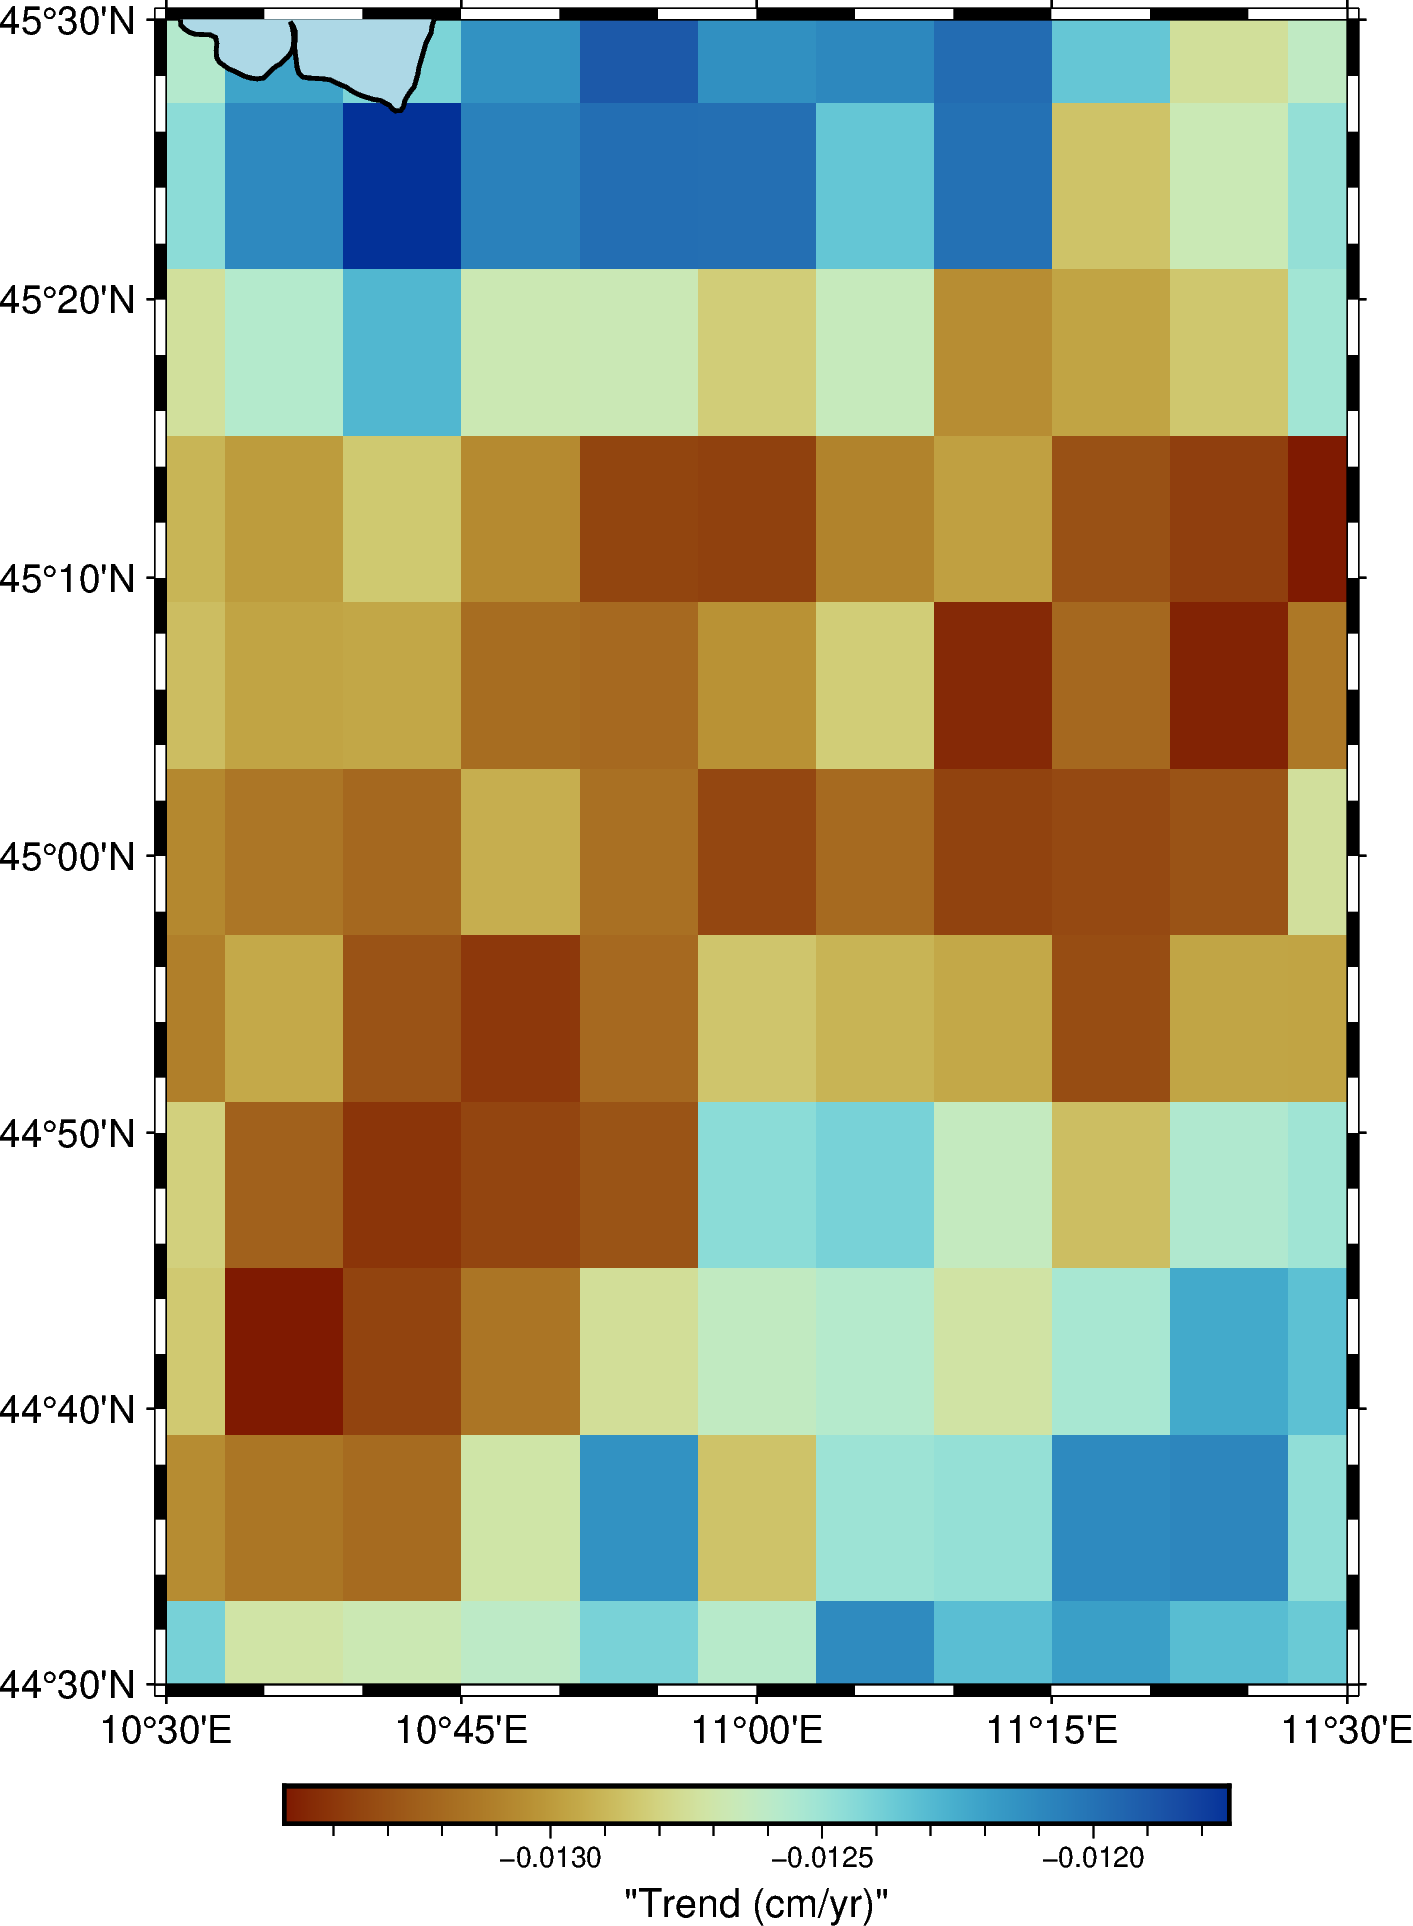

In [38]:
# Build grid
grd_trend = make_grid(trend_map, lon, lat, name="trend_cm_per_year")

region = [lon.min(), lon.max(), lat.min(), lat.max()]  # [W, E, S, N]

fig = pygmt.Figure()

fig.grdimage(
    grid=grd_trend,
    region=region,
    projection="M10c",     # simple Mercator, 10 cm width
    cmap="roma",           # nice diverging cmap, change if you prefer
    frame=["xaf", "yaf", "WSne"],
)

fig.coast(
    region=region,
    shorelines="1p,black",
    borders="1/0.5p,black",
    water="lightblue",
    resolution="f",    # full resolution
)


fig.colorbar(
    frame='x+l"Trend (cm/yr)"'
)

fig.show()


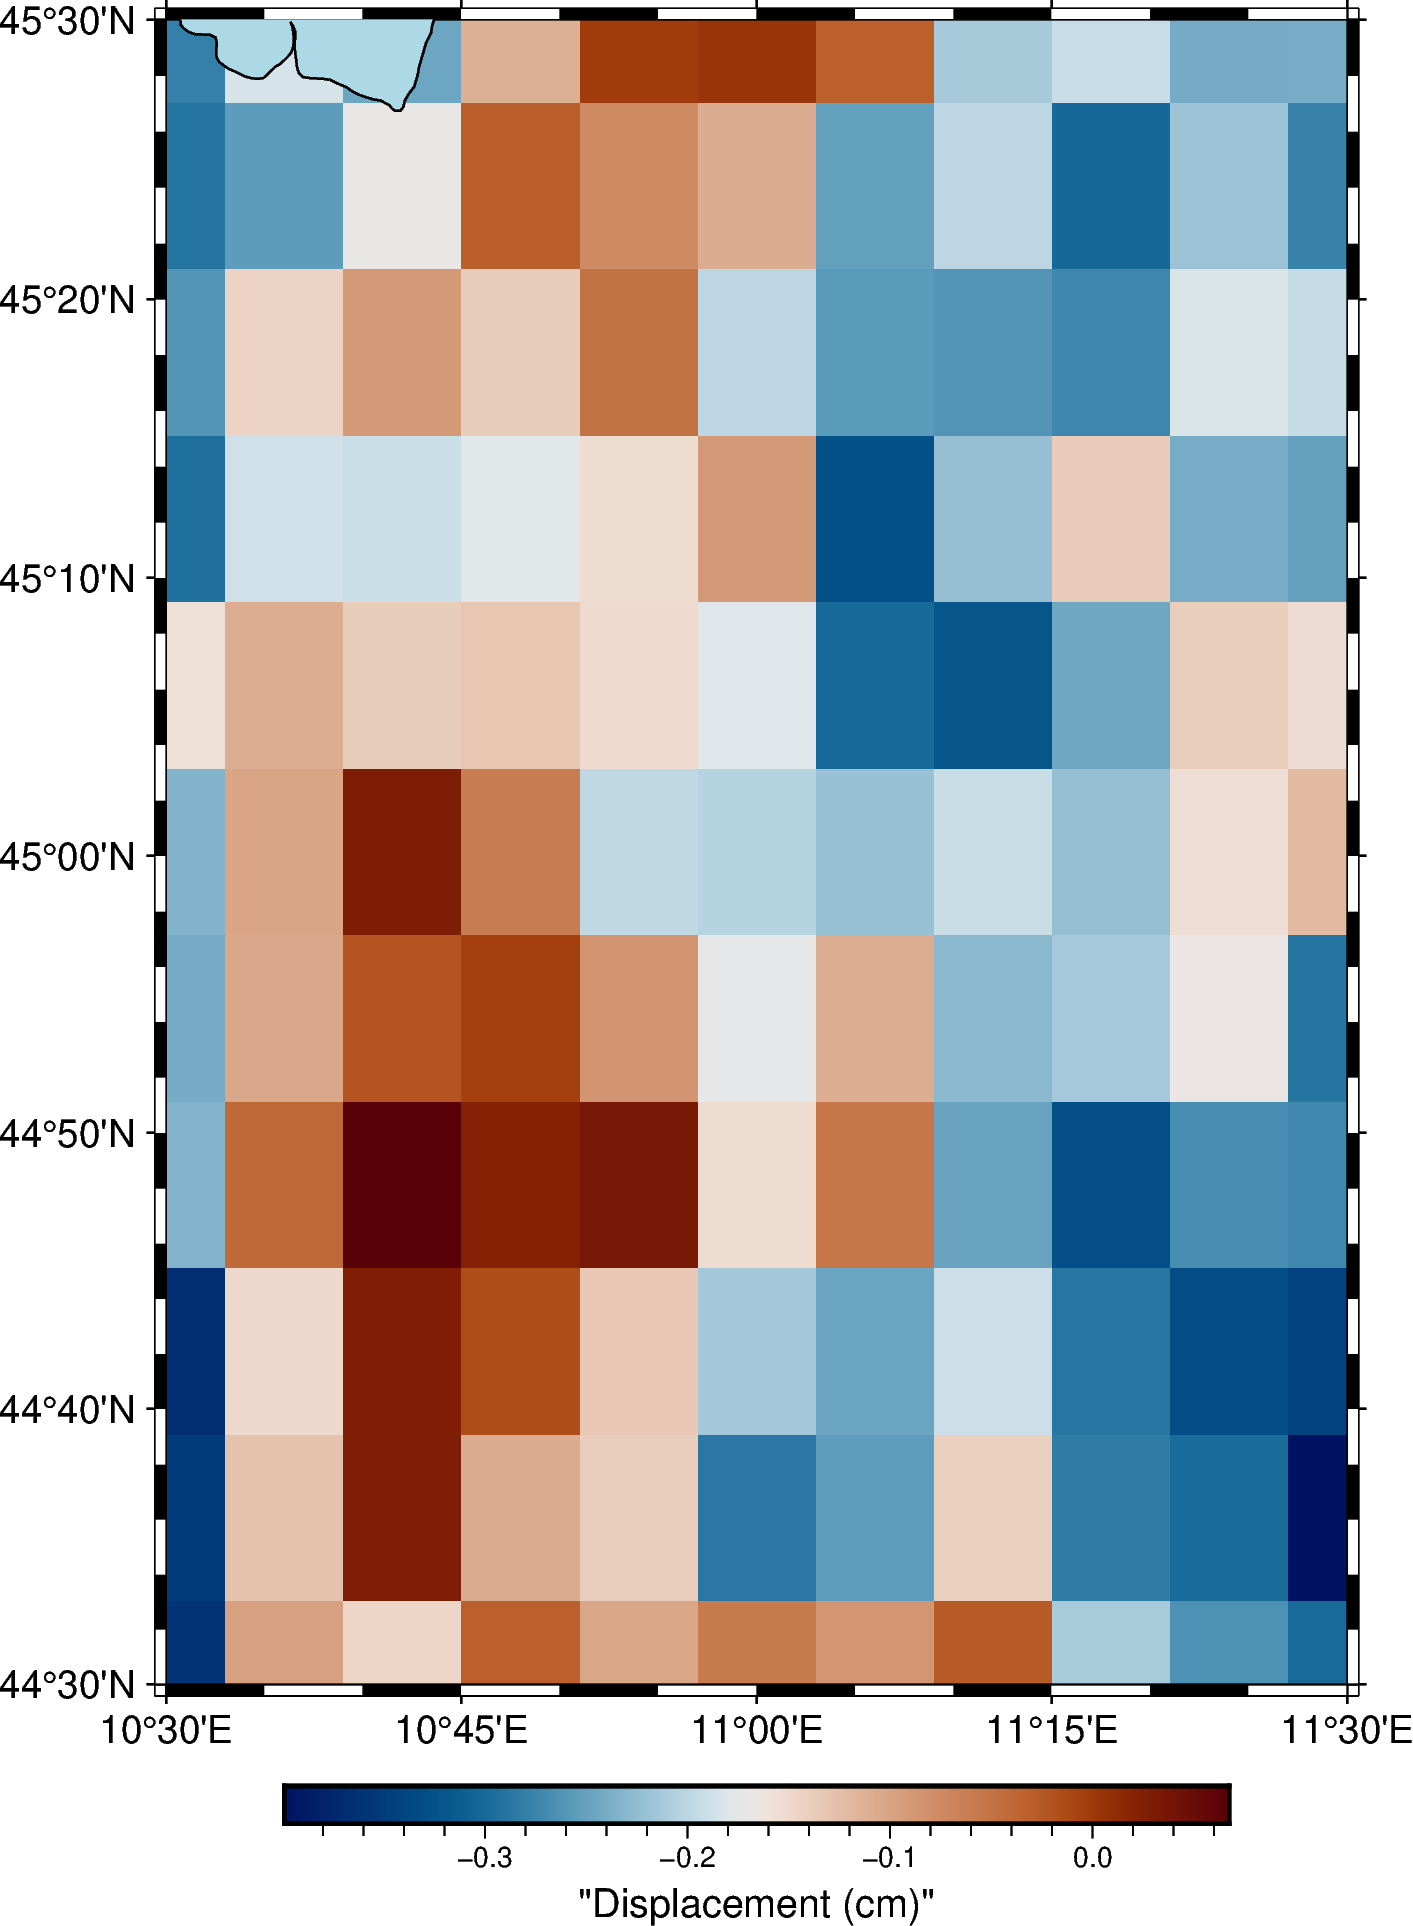

In [39]:
# Choose an epoch index
k = uz_total_noisy_cm.shape[0] // 2   # middle epoch
snap = uz_total_noisy_cm[k, :, :]     # (Ny, Nx), in cm

grd_snap = make_grid(snap, lon, lat, name="uz_cm")

fig2 = pygmt.Figure()

fig2.grdimage(
    grid=grd_snap,
    region=region,
    projection="M10c",
    cmap="vik",              # another good diverging cmap
    frame=["xaf", "yaf", "WSne"],
)

fig2.coast(
    region=region,
    shorelines="0.5p,black",
    borders="1/0.5p,black",
    water="lightblue",
)

fig2.colorbar(
    frame='x+l"Displacement (cm)"'
)

fig2.show()


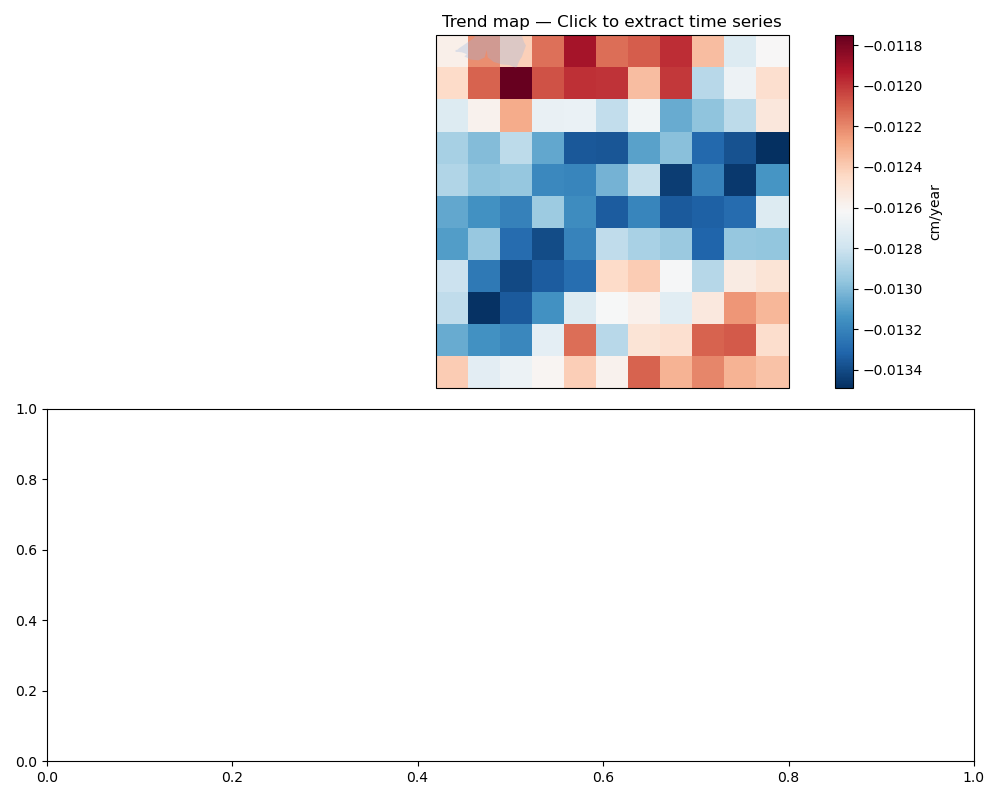

In [40]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load synthetic noisy deformation
# ds = xr.open_dataset("/home/ubuntu/work/uz_total_noisy_cm.nc")
uz = ds["uz_cm"].values
lat = ds["lat"].values
lon = ds["lon"].values

# ---- compute trend map ----
def trend(x):
    t = np.arange(len(x))
    m = np.linalg.lstsq(np.vstack([t, np.ones_like(t)]).T, x, rcond=None)[0][0]
    return m * 365.25

trend_map = np.apply_along_axis(trend, 0, uz)

# -----------------------------------
# FIGURE
# -----------------------------------
fig = plt.figure(figsize=(10, 8))

projection = ccrs.PlateCarree()

ax_map = plt.subplot(2, 1, 1, projection=projection)
ax_ts  = plt.subplot(2, 1, 2)

# Draw trend map
im = ax_map.pcolormesh(lon, lat, trend_map, cmap="RdBu_r", transform=projection)
ax_map.add_feature(cfeature.COASTLINE.with_scale("10m"))
ax_map.add_feature(cfeature.BORDERS.with_scale("10m"))
ax_map.add_feature(cfeature.LAKES.with_scale("10m"), alpha=0.3)

ax_map.set_title("Trend map — Click to extract time series")
plt.colorbar(im, ax=ax_map, label="cm/year")


# -----------------------------------
# CLICK CALLBACK
# -----------------------------------
def onclick(event):
    if event.inaxes != ax_map:
        return

    lon_pt = event.xdata
    lat_pt = event.ydata

    iy = np.argmin(np.abs(lat - lat_pt))
    ix = np.argmin(np.abs(lon - lon_pt))

    ts = uz[:, iy, ix]

    ax_ts.cla()
    ax_ts.plot(ts, "k-")
    ax_ts.set_title(f"Time series at Lat={lat_pt:.4f}, Lon={lon_pt:.4f}")
    ax_ts.set_xlabel("Time index")
    ax_ts.set_ylabel("cm")
    ax_ts.grid(True)

    fig.canvas.draw_idle()

fig.canvas.mpl_connect("button_press_event", onclick)

plt.tight_layout()
plt.show()


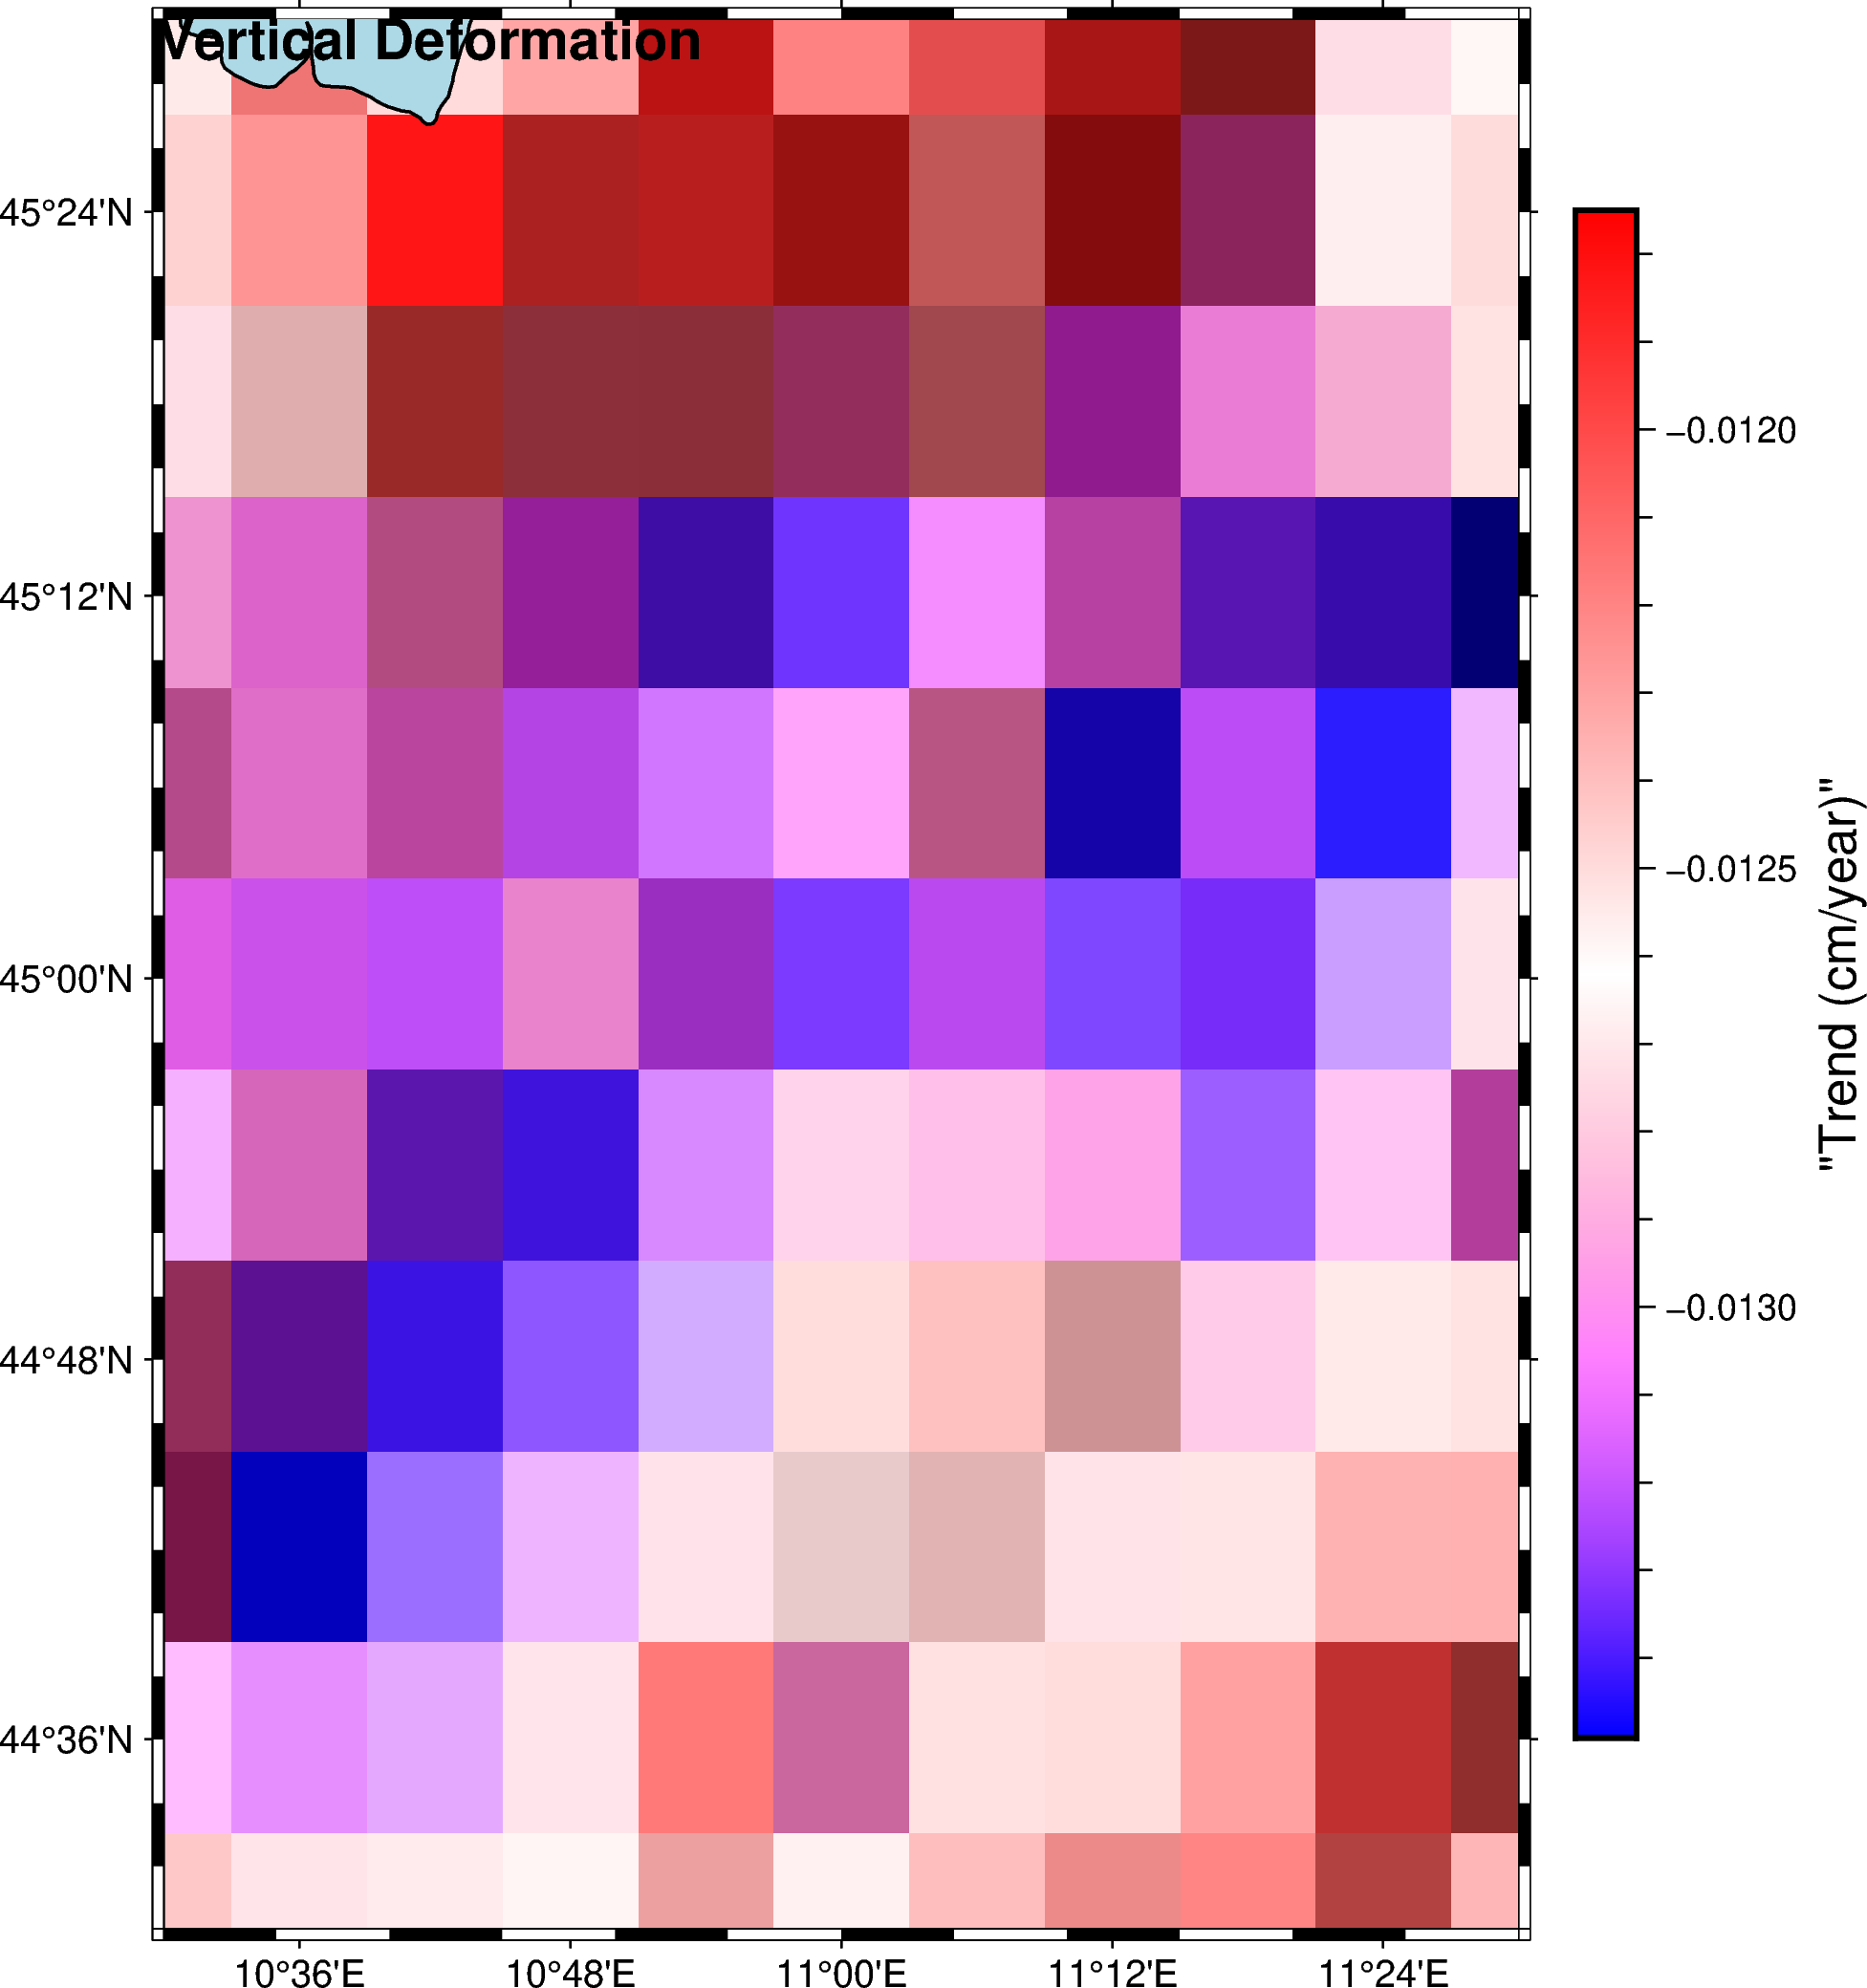

In [41]:
import pygmt
import numpy as np

grd_trend = make_grid(trend_map, lon, lat)
region = [lon.min(), lon.max(), lat.min(), lat.max()]

fig = pygmt.Figure()

fig.grdimage(
    grid=grd_trend,
    region=region,
    projection="M12c",
    cmap="polar",      # VERY clean diverging colormap
    shading=True,
    frame=["WSne", "xa0.2f", "ya0.2f"],
)

fig.coast(
    region=region,
    resolution="f",           # full resolution coastlines
    shorelines="0.7p,black",
    borders="1/0.5p,black",
    water="lightblue",
)

fig.colorbar(
    frame='x+l"Trend (cm/year)"',
    position="JMR+o0.5c/0c"
)

fig.text(
    x=lon.min() + 0.01,
    y=lat.max() - 0.01,
    text="Trend of Synthetic Vertical Deformation",
    font="14p,Helvetica-Bold",
)

fig.savefig("trend_map_pub.png", dpi=500)
fig.show()


In [48]:
import numpy as np
import xarray as xr

# ---------- 1. PICK DATA SOURCE ----------
if 'uz_total_noisy_cm' in globals():
    uz_cm = uz_total_noisy_cm
    print("Using in-memory array: uz_total_noisy_cm")
elif 'ds' in globals() and isinstance(ds, xr.Dataset) and 'uz_cm' in ds:
    uz_cm = ds['uz_cm'].values
    print("Using ds['uz_cm'] from in-memory Dataset ds")
else:
    ds = xr.open_dataset("/home/ubuntu/work/uz_total_noisy_cm.nc")
    uz_cm = ds['uz_cm'].values
    print("Loaded ds['uz_cm'] from file")

print("uz_cm shape (T, Ny, Nx):", uz_cm.shape)
T, Ny, Nx = uz_cm.shape

# ---------- 2. BUILD DATA MATRIX FOR ICA ----------
# shape: (T, Ny*Nx) – rows = time, cols = pixels
X = uz_cm.reshape(T, Ny * Nx)

# remove spatial mean (column-wise)
X_mean = X.mean(axis=0, keepdims=True)
Xc = X - X_mean

print("Xc shape:", Xc.shape)
print("Mean of |Xc|:", float(np.mean(np.abs(Xc))))
print("Std of Xc:", float(np.std(Xc)))


Using in-memory array: uz_total_noisy_cm
uz_cm shape (T, Ny, Nx): (5326, 11, 11)
Xc shape: (5326, 121)
Mean of |Xc|: 0.2931850510139574
Std of Xc: 0.36293246373631466


In [49]:
from sklearn.decomposition import FastICA

# ---------- 3. FASTICA ----------
# number of components: you can increase if you want (<= Ny*Nx)
n_components = min(10, Ny * Nx)
print("Using n_components =", n_components)

ica = FastICA(
    n_components=n_components,
    whiten='unit-variance',
    random_state=0,
    max_iter=500,
)

S = ica.fit_transform(Xc)   # (T, k): temporal ICs
A = ica.mixing_             # (S, k): spatial mixing matrix

print("S shape (T, k):", S.shape)
print("A shape (S, k):", A.shape)

# ---------- 4. CHECK RECONSTRUCTION ----------
X_rec = S @ A.T + X_mean    # add back mean to compare with original
rmse = np.sqrt(np.mean((X - X_rec) ** 2))
print("Reconstruction RMSE (cm):", float(rmse))


Using n_components = 10
S shape (T, k): (5326, 10)
A shape (S, k): (121, 10)
Reconstruction RMSE (cm): 0.06427717200274537


In [50]:
# ---------- 5. RESHAPE SPATIAL ICS ----------
# A: (S, k) = (Ny*Nx, k)
spatial_ICs = A.T.reshape(n_components, Ny, Nx)   # (k, Ny, Nx)

print("spatial_ICs shape (k, Ny, Nx):", spatial_ICs.shape)

# quick stats for first 3 ICs
for i in range(min(3, n_components)):
    print(f"IC {i}: spatial min={spatial_ICs[i].min():.4e}, "
          f"max={spatial_ICs[i].max():.4e}, "
          f"temporal std={S[:, i].std():.4e}")


spatial_ICs shape (k, Ny, Nx): (10, 11, 11)
IC 0: spatial min=-6.8492e-02, max=4.2354e-02, temporal std=1.0000e+00
IC 1: spatial min=-1.8602e-02, max=5.3495e-02, temporal std=1.0000e+00
IC 2: spatial min=3.1056e-01, max=3.6274e-01, temporal std=1.0000e+00


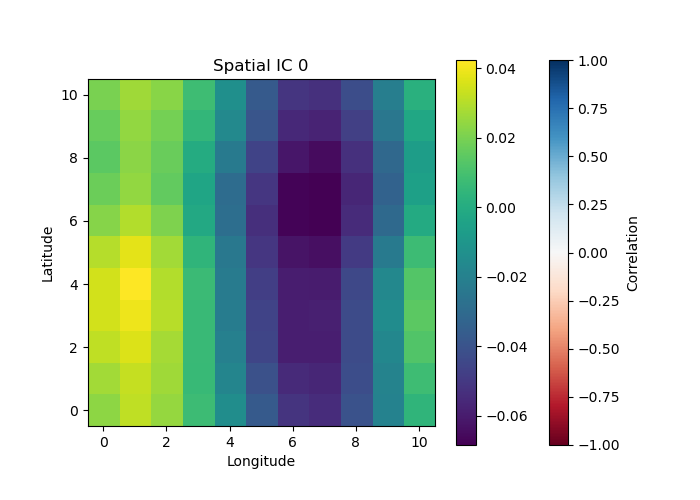

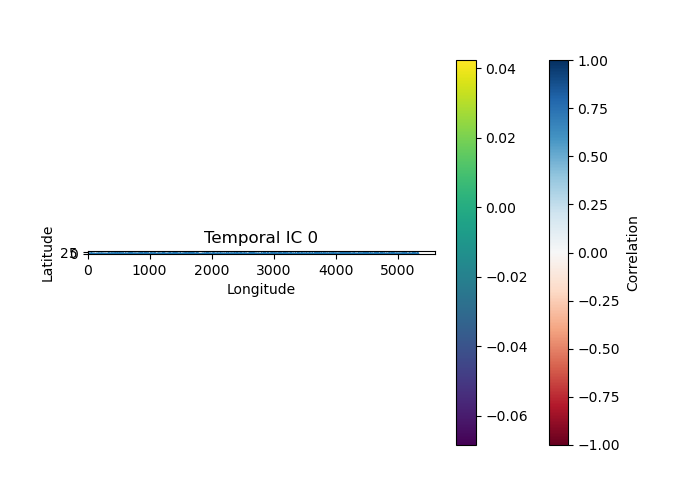

In [51]:
import matplotlib.pyplot as plt

plt.imshow(spatial_ICs[0], origin="lower")
plt.colorbar()
plt.title("Spatial IC 0")
plt.show()

plt.plot(S[:, 0])
plt.title("Temporal IC 0")
plt.show()


In [52]:
# ---------- 6. RECONSTRUCT ONE IC AS A MAP TIME SERIES ----------

ic_idx = 0   # change this to test different components

# contribution of IC ic_idx only
S_ic = S[:, [ic_idx]]         # (T, 1)
A_ic = A[:, [ic_idx]]         # (S, 1)
X_ic = S_ic @ A_ic.T          # (T, S)

# add back mean if you want "full" field of this component
X_ic_full = X_ic + X_mean     # still (T, S)

# reshape to (T, Ny, Nx)
uz_ic_cm = X_ic_full.reshape(T, Ny, Nx)

print("uz_ic_cm shape:", uz_ic_cm.shape)
print("uz_ic_cm min/max:", float(uz_ic_cm.min()), float(uz_ic_cm.max()))
print("Done: IC", ic_idx, "reconstructed as uz_ic_cm (cm)")


uz_ic_cm shape: (5326, 11, 11)
uz_ic_cm min/max: -0.1629941666718306 0.17210930872408234
Done: IC 0 reconstructed as uz_ic_cm (cm)


In [ ]:
# This script performs joint inversion to separate load-induced and poroelastic-induced vertical displacements
# from the noisy synthetic vertical displacement data using FFT-based methods
import numpy as np
import xarray as xr

# ---------------------------------------------------------
# 1. SELECT DATA SOURCE (memory first)
# ---------------------------------------------------------
try:
    assert 'ds' in globals()
    assert isinstance(ds, xr.Dataset)
    print("→ Using in-memory dataset: ds")
except:
    print("→ Loading dataset from file")
    ds = xr.open_dataset("/home/ubuntu/work/uz_total_noisy_cm.nc")

uz_cm = ds['uz_cm'].values      # (T, lat, lon)
lat   = ds['lat'].values
lon   = ds['lon'].values
time  = ds['time'].values

T, Ny, Nx = uz_cm.shape
uz_m = uz_cm / 100.0    # cm → m
print("Input shape:", uz_m.shape)

# ---------------------------------------------------------
# 2. PARAMETERS CLASS
# ---------------------------------------------------------
class Params:
    E     = 1e9
    nu    = 0.25
    rho_w = 1000
    g     = 9.81
    alpha = 0.8
    Hg    = 150
    Seff  = 0.2
    dx    = 10000
    dy    = 10000
    a     = 3000    # kernel radius for both kernels (can split later)

P = Params()

# ---------------------------------------------------------
# 3. BUILD GREEN FUNCTION FFT KERNELS
# ---------------------------------------------------------
G_load_z = build_elastic_kernel(P.E, P.nu, P.dx, P.dy, P.a, Nx, Ny)
G_poro_z = build_poroelastic_kernel(P.E, P.nu, P.alpha, P.Hg,
                                    P.dx, P.dy, P.a, Nx, Ny)

G_load_fft, G_poro_fft = build_fft_kernels(G_load_z, G_poro_z)

# ---------------------------------------------------------
# 4. JOINT INVERSION PREPARATION
# ---------------------------------------------------------
GL  = G_load_fft
GP  = G_poro_fft
GLC = np.conj(GL)
GPC = np.conj(GP)

# small diagonal regularization (prevent division by 0)
lambda_L = 0.05 * np.max(np.abs(GL))
lambda_P = 0.05 * np.max(np.abs(GP))
eps = 1e-20

A11 = np.abs(GL)**2 + lambda_L**2
A22 = np.abs(GP)**2 + lambda_P**2
A12 = GLC * GP
A21 = GPC * GL

det = A11 * A22 - A12 * A21
det = det + eps

# container
delta_p = np.zeros_like(uz_m)

# ---------------------------------------------------------
# 5. JOINT INVERSION LOOP
# ---------------------------------------------------------
for t_idx in range(T):

    U = np.fft.fft2(uz_m[t_idx])  # forward FFT of displacement

    b1 = A12 * U          # corresponds to poro part
    b2 = A22 * U          # corresponds to load part

    # Solve 2×2 system
    L_hat = (b1 * A22 - b2 * A12) / det    # load pressure (unused)
    P_hat = (A11 * b2 - A21 * b1) / det    # pore pressure ← what we want

    # back to physical space
    delta_p[t_idx] = np.fft.ifft2(P_hat).real

    if (t_idx+1) % max(1, T//10) == 0:
        print(f"Inversion step: {t_idx+1}/{T}")

# ---------------------------------------------------------
# 6. CONVERT PORE PRESSURE TO SG (mm)
# ---------------------------------------------------------
Sg_inv_mm = P.Seff * delta_p / (P.rho_w * P.g) * 1000.0

print("Inversion complete.")
print("Sg: mean=", float(np.mean(Sg_inv_mm)),
      "std=", float(np.std(Sg_inv_mm)),
      "min/max=", float(np.min(Sg_inv_mm)), float(np.max(Sg_inv_mm)))


→ Using in-memory dataset: ds
Input shape: (5326, 11, 11)
Inversion step: 532/5326
Inversion step: 1064/5326
Inversion step: 1596/5326
Inversion step: 2128/5326
Inversion step: 2660/5326
Inversion step: 3192/5326
Inversion step: 3724/5326
Inversion step: 4256/5326
Inversion step: 4788/5326
Inversion step: 5320/5326
Inversion complete.
Sg: mean= 2.1933078679208438e-30 std= 6.911331090134322e-28 min/max= -8.245611174577533e-28 2.4878733482811184e-27


In [43]:

# ============================================
# 8. SAVE RESULT
# ============================================
out_file = "/home/ubuntu/work/Sg_joint_inverted_mm.nc"
da = xr.DataArray(
    Sg_inv_mm,
    dims=("time", "lat", "lon"),
    coords={"time": time, "lat": lat, "lon": lon},
    name="Sg_inv_mm",
)
da.attrs["units"] = "mm"
da.attrs["description"] = (
    "Groundwater storage anomaly from JOINT spectral inversion "
    "(Carlson-style) using elastic + poroelastic Green's functions"
)
da.to_netcdf(out_file)
print("Saved:", out_file)


Saved: /home/ubuntu/work/Sg_joint_inverted_mm.nc


In [44]:
import numpy as np
import xarray as xr

# Load inverted Sg
ds_inv = xr.open_dataset("/home/ubuntu/work/Sg_joint_inverted_mm.nc")
Sg_inv = ds_inv["Sg_inv_mm"].values     # (T,Ny,Nx)
lat_inv = ds_inv["lat"].values
lon_inv = ds_inv["lon"].values
time_inv = ds_inv["time"].values

# ---- LOAD TRUE Sg FROM W3RA ----
ds_w3ra = xr.open_dataset("/home/ubuntu/work/w3ra_Test_Region_10km.nc")

def load_Sg_true():
    vars_sg = [v for v in ds_w3ra.variables if v.startswith("Sg_EU_")]
    vars_sg_sorted = sorted(vars_sg, key=lambda v: int(v.split("_EU_")[1]))

    all_data = []
    all_time = []

    for v in vars_sg_sorted:
        year = int(v.split("_EU_")[1])
        arr = ds_w3ra[v].values              # (T,Ny,Nx)
        t   = ds_w3ra[f"time_{year}"].values # days since start of year

        # convert to datetimes
        base = np.datetime64(f"{year}-01-01")
        t_dates = base + t.astype("timedelta64[D]")

        all_data.append(arr)
        all_time.append(t_dates)

    Sg = np.concatenate(all_data, axis=0)
    T = np.concatenate(all_time, axis=0)

    # anomalies (remove temporal mean)
    Sg_anom = Sg - Sg.mean(axis=0, keepdims=True)

    return Sg_anom, T

Sg_true, time_true = load_Sg_true()
print("Loaded true Sg:", Sg_true.shape)


Loaded true Sg: (5326, 11, 11)


In [45]:
print("Times match:", Sg_inv.shape[0] == Sg_true.shape[0])
print("Grid match lat:", np.allclose(lat_inv, ds_w3ra["lat"].values))
print("Grid match lon:", np.allclose(lon_inv, ds_w3ra["lon"].values))


Times match: True
Grid match lat: True
Grid match lon: True


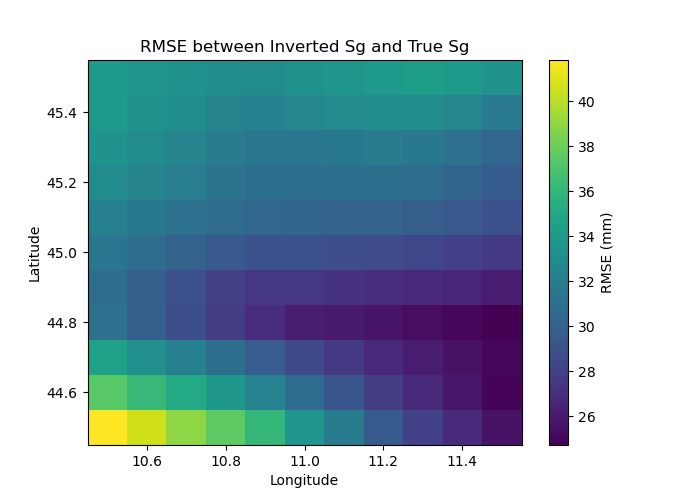

In [46]:
rmse_map = np.sqrt(np.mean((Sg_inv - Sg_true)**2, axis=0))

import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.pcolormesh(lon_inv, lat_inv, rmse_map, cmap="viridis")
plt.colorbar(label="RMSE (mm)")
plt.title("RMSE between Inverted Sg and True Sg")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


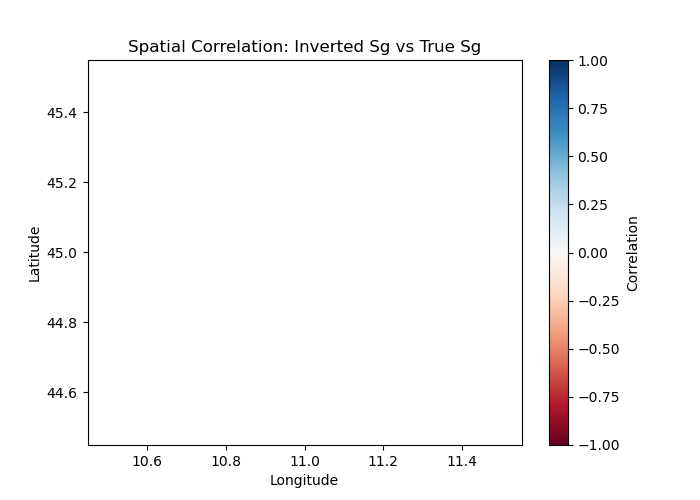

In [47]:
corr_map = np.zeros((len(lat_inv), len(lon_inv)))

for iy in range(len(lat_inv)):
    for ix in range(len(lon_inv)):
        a = Sg_inv[:, iy, ix]
        b = Sg_true[:, iy, ix]
        if np.std(a) < 1e-6 or np.std(b) < 1e-6:
            corr_map[iy, ix] = np.nan
        else:
            corr_map[iy, ix] = np.corrcoef(a, b)[0,1]

plt.figure(figsize=(7,5))
plt.pcolormesh(lon_inv, lat_inv, corr_map, cmap="RdBu", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Spatial Correlation: Inverted Sg vs True Sg")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


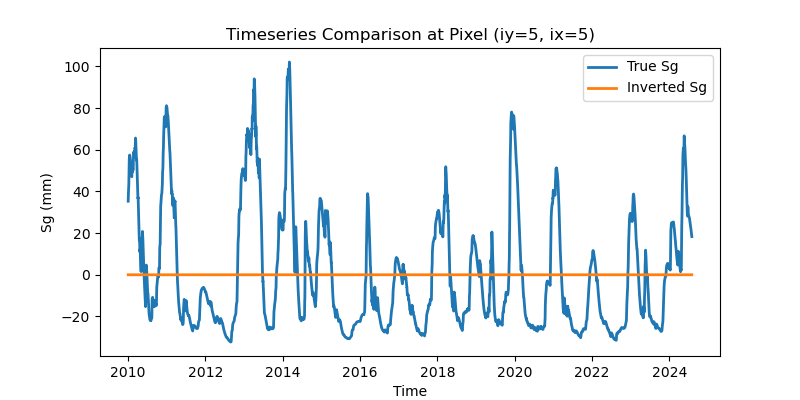

In [39]:
iy, ix = 5, 5  # choose a pixel

plt.figure(figsize=(8,4))
plt.plot(time_inv, Sg_true[:,iy,ix], label="True Sg", lw=2)
plt.plot(time_inv, Sg_inv[:,iy,ix], label="Inverted Sg", lw=2)
plt.legend()
plt.ylabel("Sg (mm)")
plt.xlabel("Time")
plt.title(f"Timeseries Comparison at Pixel (iy={iy}, ix={ix})")
plt.show()


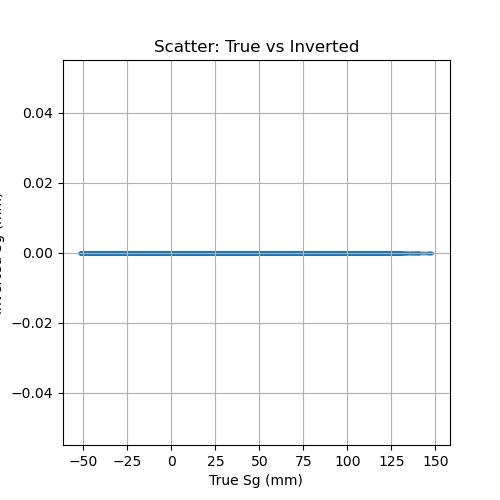

In [40]:
mask = ~np.isnan(Sg_true)
plt.figure(figsize=(5,5))
plt.scatter(Sg_true[mask], Sg_inv[mask], s=4, alpha=0.4)
plt.xlabel("True Sg (mm)")
plt.ylabel("Inverted Sg (mm)")
plt.title("Scatter: True vs Inverted")
plt.grid(True)
plt.show()


In [54]:
%%bash
cat << 'EOF' > trend_viewer.sh
#!/usr/bin/env bash

# Input grid
GRID="trend_map.nc"
OUT="trend_map"

# safely extract region
REG=$(gmt grdinfo -T $GRID | grep "WESN" | awk '{print "-R" $2"/" $3"/" $4"/" $5}')

# start GMT
gmt begin $OUT png

    # colormap
    gmt makecpt -Chaxby -T-2/2/0.1

    # grid image
    gmt grdimage $GRID $REG -JM12c -C

    # coastline (your region is land, but OK)
    gmt coast $REG -JM12c -W0.5p -Df

    # colorbar
    gmt colorbar -Bxa1f0.5+l"Trend (cm/yr)"

gmt end
# gmt begin trend_viewer png

#     gmt makecpt -Croma -T-2/2/0.1
#     gmt grdimage trend_map.nc -JM15c -C -Baf
#     gmt coast -W0.5p -N1/0.5p -Df
#     gmt colorbar -Dx15c/0.5c+w12c/0.4c+h -Baf+l"Trend (cm/yr)"

# gmt end


# gmt begin trend_viewer html

#     # Color palette for deformation trend (cm/year)
#     gmt makecpt -Croma -T-2/2/0.1

#     # Plot trend map (2D grid)
#     gmt grdimage trend_map.nc -JM15c -C -Baf

#     # Add coastlines and borders
#     gmt coast -W0.5p -N1/0.5p -Df

#     # Color bar
#     gmt colorbar -Dx15c/0.5c+w12c/0.4c+h -Baf+l"Trend (cm/yr)"

# gmt end show
EOF


In [55]:
!chmod +x trend_viewer.sh


In [56]:
!./trend_viewer.sh


grdinfo [WARNING]: Guessing of registration in conflict between x and y, using gridline
gmt [WARNING]: Guessing of registration in conflict between x and y, using gridline
grdimage [WARNING]: Guessing of registration in conflict between x and y, using gridline


In [ ]:
from IPython.display import Image
Image("trend_map.png")


In [42]:
!gmt begin test png
!gmt coast -R10/12/44/46 -JM10c -Baf
!gmt end


coast [ERROR]: Must specify at least one of -C, -G, -S, -E, -I, -N, -Q and -W


In [ ]:
from IPython.display import IFrame
IFrame("trend_viewer.html", width=1000, height=800)
